>[Import Libraries and Data](#scrollTo=TsK67dXyu5Ly)

>[Summary of the Data](#scrollTo=WAiAC_Cz0AGi)

>[Exploration Data Analysis](#scrollTo=OY0Vx_4tLRZG)

>>[Distributions of Numerical Predictors](#scrollTo=pRTG1TuQyDWO)

>>[Count Plots of Categorical Predictors and Response Variable](#scrollTo=m1CEn_8YyQ8J)

>>[Feature Engineering](#scrollTo=XD4LgziYRZ5o)

>>>[Why different models use different feature sets](#scrollTo=XD4LgziYRZ5o)

>>[Multicollinearity](#scrollTo=-ZqQsBEyyTy_)

>>[Relationship Between Time and Death of Patients](#scrollTo=fBtnmmVfSlqp)

>[Outlier Analysis](#scrollTo=cGpmlFSYvE_u)

>>>[Clinically Implausibible Values](#scrollTo=caGASy7evzxw)

>[Baseline Model: Logistic Regression Model](#scrollTo=4zHW5ZUId8rQ)

>>>[Final Feature Representation and Need for Retraining](#scrollTo=qoLH04aFRZ5z)

>[K-Nearest Neighbors Model](#scrollTo=quZJmihDgbrb)

>[Logistic Regression with Regularization](#scrollTo=wAMKs3SQx2P0)

>>[Motivation For Regularized Logistic Regression:](#scrollTo=wAMKs3SQx2P0)

>>[Lasso Regularization (L1)](#scrollTo=wAMKs3SQx2P0)

>>[Ridge Regularization (L2)](#scrollTo=3v6z7TCaySE1)

>>[Lasso (L1) and Ridge (L2) Regularization Logistic Regression Analysis and Interpretation](#scrollTo=71fYPzCadDvF)

>[Regularized Polynomial Degree of 3 Logistic Regression](#scrollTo=pW6JDSiIKOSR)

>[Decision Tree](#scrollTo=CaBh72b9xmgN)

>>>[Decision Tree Analysis and Interpretation](#scrollTo=gwbWcWiv2LoW)

>[Support Vector Machine](#scrollTo=ykyiAfd2cXNA)

>>[SVM path: from flexible RBF to a calibrated linear margin](#scrollTo=I7pJD5gpBj4-)

>>[Final Consolidation of Feature Space and Model Retraining](#scrollTo=JzPOilwkRZ52)

>[Final model comparison: CV vs Test performance](#scrollTo=vLWfDLDbBj5A)

>>[Model Performance Comparison](#scrollTo=eTNYLI66RZ53)

>>>[Model Performance Summary from the Visualizations](#scrollTo=bZT6kuoXRZ53)

>>>[Clinical Interpretation of Feature Importance](#scrollTo=Qp4USRt_BcuW)

>>[Model Comparison Summary](#scrollTo=OIFRwc6mHGxt)

>>[Conclusions and Future Work](#scrollTo=e-WIFZSWCHRB)

>>[Bibliography](#scrollTo=dMxqF8awa5Tn)



# Import Libraries and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, StratifiedKFold,
    GridSearchCV, cross_validate, cross_val_predict
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, precision_recall_curve,
    average_precision_score, confusion_matrix
)
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
import os
from sklearn.base import clone
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
from utils import *
random_state=42



In [2]:
!git clone https://github.com/Protprommart/CSCI109A_Project.git

fatal: destination path 'CSCI109A_Project' already exists and is not an empty directory.


In [3]:
df = pd.read_csv('CSCI109A_Project/heart_failure_clinical_records_dataset.csv')

In [4]:
num_col = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']
category_list = ['anaemia','diabetes','high_blood_pressure','sex','smoking','DEATH_EVENT']
scaled_list = ['age_scaled', 'creatinine_phosphokinase_scaled', 'ejection_fraction_scaled', 'platelets_scaled', 'serum_creatinine_scaled', 'serum_sodium_scaled', 'time_scaled']

In [5]:
for col in category_list:
  df[col] = df[col].astype('category')

In [6]:
#apply standardization to all the columns
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df.loc[:, num_col])
scaled_df = pd.DataFrame(scaled_df, columns=scaled_list)
new_df = pd.concat([scaled_df, df], axis=1)

# Summary of the Data

The original dataset consists of 299 observations and 12 primary features that describe the clinical, physiological, and demographic characteristics of heart failure patients. After preprocessing, which included standardization, encoding, and the creation of additional scaled variables, the refined analytical dataset contains 20 variables in total. Numerical variables are stored as float64 or int64 data types, while categorical variables are encoded as category types. No missing or inconsistent entries were found, indicating that the dataset has been fully cleaned, transformed, and validated for further analysis.



In [7]:
print("Shape of the dataset:", new_df.shape)
print("\nData types:\n", new_df.dtypes)
print("\nSummary Info:")
new_df.info()

Shape of the dataset: (299, 20)

Data types:
 age_scaled                          float64
creatinine_phosphokinase_scaled     float64
ejection_fraction_scaled            float64
platelets_scaled                    float64
serum_creatinine_scaled             float64
serum_sodium_scaled                 float64
time_scaled                         float64
age                                 float64
anaemia                            category
creatinine_phosphokinase              int64
diabetes                           category
ejection_fraction                     int64
high_blood_pressure                category
platelets                           float64
serum_creatinine                    float64
serum_sodium                          int64
sex                                category
smoking                            category
time                                  int64
DEATH_EVENT                        category
dtype: object

Summary Info:
<class 'pandas.core.frame.DataFrame'>
RangeIn

Feature Descriptions:

age: Numerical. The age of the patient in years.
anaemia: Categorical. Indicates whether the patient has anaemia, defined as a decrease in red blood cells or hemoglobin (1 = Yes, 0 = No).

creatinine_phosphokinase: Numerical. The level of the CPK enzyme (mcg/L) in the blood, which may increase due to tissue damage.

diabetes: Categorical. Indicates whether the patient has diabetes (1 = Yes, 0 = No).

ejection_fraction: Numerical. The percentage of blood leaving the heart at each contraction; lower values indicate reduced cardiac function.

high_blood_pressure: Categorical. Indicates whether the patient has high blood pressure (1 = Yes, 0 = No).

platelets: Numerical. The platelet count in the blood (kiloplatelets/mL).

serum_creatinine: Numerical. The level of creatinine in the blood (mg/dL), where higher levels indicate impaired kidney function.

serum_sodium: Numerical. The level of sodium in the blood (mEq/L); low values can indicate fluid imbalance or heart failure severity.

sex: Categorical. The biological sex of the patient (1 = Male, 0 = Female).

smoking: Categorical. Indicates whether the patient is a smoker (1 = Yes, 0 = No).

time: Numerical. The follow-up period (in days) during which the patient was observed. D

EATH_EVENT: Categorical. The target variable; indicates whether the patient died during the follow-up period (1 = Yes, 0 = No).

Scaled features (e.g., age_scaled, serum_creatinine_scaled, etc.): Numerical.
Standardized (z-score normalized) versions of the numerical features for use in modeling and analysis.


In [8]:
desc_stats = new_df.describe().T
display(desc_stats[['mean', 'min', 'max', 'std']])

,mean,min,max,std
age_scaled,5.703353e-16,-1.754448,2.877170,1.001676
creatinine_phosphokinase_scaled,0.000000e+00,-0.576918,7.514640,1.001676
ejection_fraction_scaled,-3.267546e-17,-2.038387,3.547716,1.001676
platelets_scaled,7.723291e-17,-2.440155,6.008180,1.001676
serum_creatinine_scaled,1.425838e-16,-0.865509,7.752020,1.001676
serum_sodium_scaled,-8.673849e-16,-5.363206,2.582144,1.001676
time_scaled,-1.901118e-16,-1.629502,1.997038,1.001676
age,6.083389e+01,40.000000,95.000000,11.894809
creatinine_phosphokinase,5.818395e+02,23.000000,7861.000000,970.287881
ejection_fraction,3.808361e+01,14.000000,80.000000,11.834841


The descriptive statistics of the numerical variables demonstrate that the dataset is well-structured and appropriately scaled. Each of the standardized features (such as age_scaled, serum_creatinine_scaled, and time_scaled) has a mean value close to zero and a standard deviation approximately equal to one, confirming that normalization was applied correctly. The unscaled variables exhibit ranges that align with clinically plausible values. For instance, patient age ranges from 40 to 95 years with a mean of approximately 60 years, serum creatinine values vary between 0.5 and 9.4 mg/dL with a mean of 1.39 mg/dL, and ejection fraction ranges from 14 to 80 percent with an average of 38.1 percent. Platelet counts display a wide spread between 25,100 and 850,000 kiloplatelets per milliliter, reflecting natural biological variability. These results confirm that all numerical features are correctly formatted, free from anomalies, and statistically consistent with expected clinical data distributions.


# Exploration Data Analysis

## Distributions of Numerical Predictors

The distribution plot of all the numerical predictors below shows us what kind of distribution are we working with in this dataset. There are highly right skewed predictors including creatinine phosphokinase and serum creatinine. Platelets and serum sodium also have some outliers, but it is not as heavily skewed as creatinine phosphokinase and serum creatinine. This is relevant to the model because  outliers can be concerning because it can impact the model to misclassify the prediction group. Further analysis of the outlier is avaiable in the Outlier Analysis Section.    

In [9]:
def histogram_plot(col_list, nrow, ncol, data, category='None', size=(10,20)):
  fig, ax = plt.subplots(nrow, ncol, figsize=size)
  ax = ax.flatten()
  if category == 'None':
    for i, col in enumerate(col_list):
      sns.histplot(data[col], ax=ax[i], bins=50, kde=True)
      ax[i].set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()
  else:
    for i, col in enumerate(col_list):
      sns.histplot(data=data, x=col, hue=category, ax=ax[i], bins=50, kde=True)
      ax[i].set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

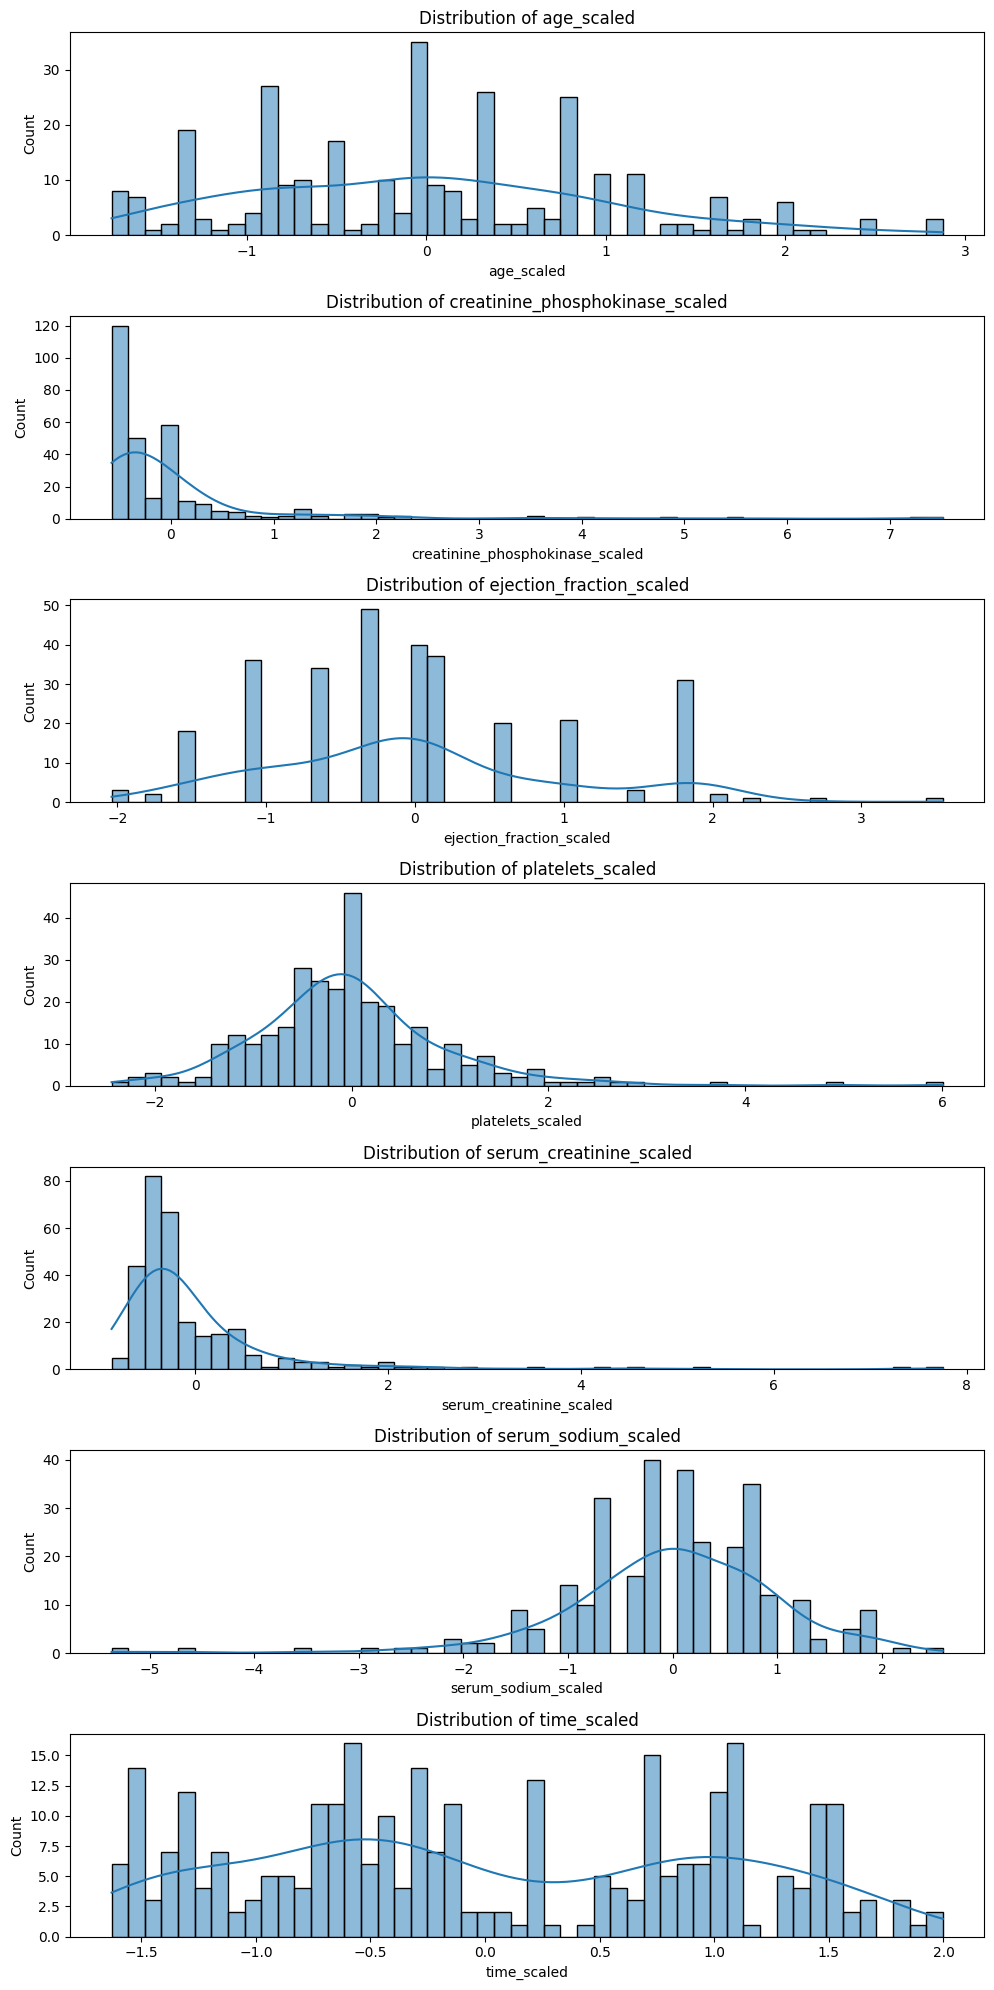

In [10]:
histogram_plot(scaled_list, nrow=7, ncol=1, data=new_df)

## Count Plots of Categorical Predictors and Response Variable

The categorical features in this data set are anaemic, diabetes, high blood pressure, sex, and smoking. The response variable is the death event. The count plot below shows that there are more records for non-anemic, non-diabetic, non-high blood pressure, male, and non-smokers group. For the response variable, we see higher counts of patient surviving than dying from heart failure. This is relevant to the process of splitting train and test data as we want to keep the ratio of the survive versus pass away patient ratio to be consistent in both train and test dataset by stratifying method.

In [11]:
def count_plot(col_list, nrow, ncol, category='None'):
  if category == 'None':
    fig, ax = plt.subplots(nrow, ncol, figsize=(10, 8))
    ax = ax.flatten()
    for i, col in enumerate(col_list):
      sns.countplot(x=df[col], ax=ax[i])
      ax[i].set_title(f'Count plot of {col}')
    plt.tight_layout()
    plt.show()
  else:
    fig, ax = plt.subplots(nrow, ncol, figsize=(10, 8))
    ax = ax.flatten()
    for i, col in enumerate(col_list):
      sns.countplot(x=df[col], ax=ax[i], hue=df[category])
      ax[i].set_title(f'Count plot of {col}')
    plt.tight_layout()
    plt.show()

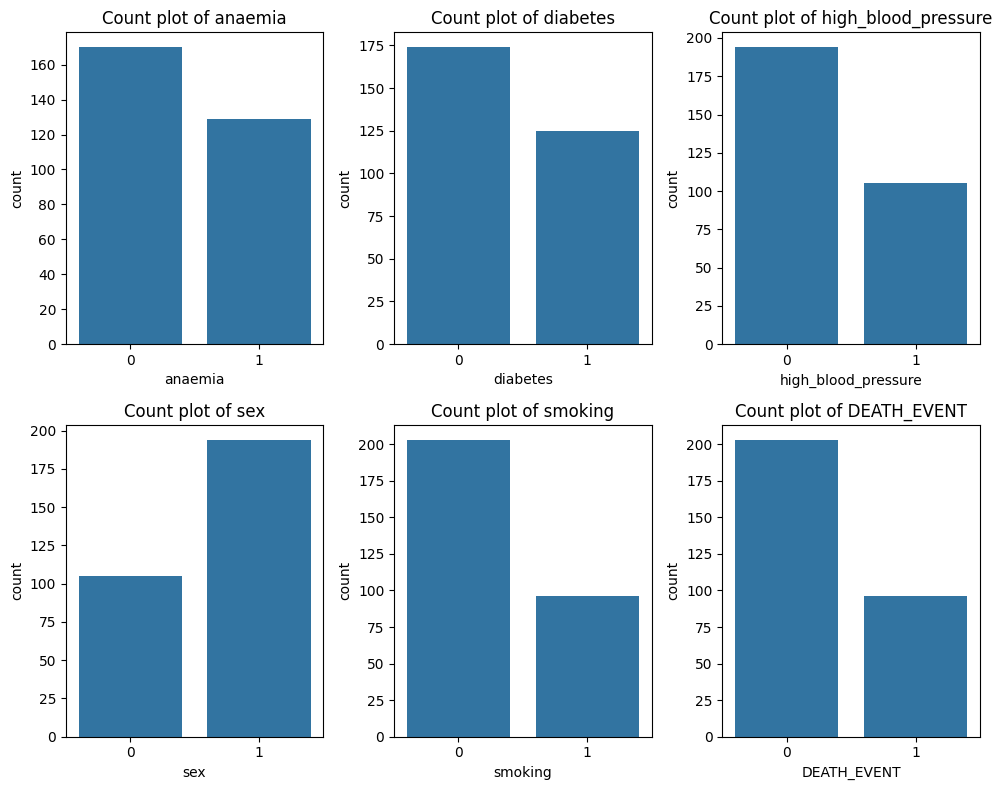

In [12]:
count_plot(category_list, nrow=2, ncol=3)

## Feature Engineering

To strengthen the predictive power of the models, we introduce three clinically informed features that capture important nonlinear relationships in heart failure. These features do not leak information and reflect patterns well-documented in cardiology:

1. **Cardiorenal Interaction** - combines kidney dysfunction and reduced cardiac output.
2. **Hyponatremia Indicator** - flags patients with low serum sodium, a strong mortality marker.
3. **Age × Ejection Fraction Interaction** - models the amplified risk seen in older patients with reduced EF.

These engineered features help linear models capture nonlinear effects and allow more flexible models to learn sharper risk boundaries.

### Why different models use different feature sets

The engineered features (cardiorenal interaction, hyponatremia flag, and age × EF interaction) represent nonlinear clinical relationships that help linear models such as Logistic Regression and Linear SVM capture effects they otherwise cannot. These models therefore use the engineered feature matrix.

In contrast, Polynomial Logistic Regression, Decision Trees, and KNN already learn nonlinear structure on their own. For these models, adding engineered interactions can distort distance metrics (KNN), duplicate patterns already captured by polynomial expansion, or add noise that does not meaningfully improve performance. These models use the original feature matrix.

To implement this distinction, two feature sets are constructed `X_original` and `X_engineered` and the comparison table automatically routes each model to the appropriate one.

In [13]:
# 1. Cardiorenal Interaction (Serum Creatinine × Ejection Fraction)

df['renal_cardio_interaction'] = df['serum_creatinine'] * df['ejection_fraction']

scaled_df['renal_cardio_interaction_scaled'] = StandardScaler().fit_transform(
    df[['renal_cardio_interaction']]
)

scaled_list.append('renal_cardio_interaction_scaled')

In [14]:
# 2. Hyponatremia Indicator (binary: sodium < 135)

df['hyponatremia_flag'] = (df['serum_sodium'] < 135).astype(int)

scaled_df['hyponatremia_flag_scaled'] = StandardScaler().fit_transform(
    df[['hyponatremia_flag']]
)

scaled_list.append('hyponatremia_flag_scaled')

print("Added: hyponatremia_flag + scaled version")


Added: hyponatremia_flag + scaled version


In [15]:
# 3. Age × Ejection Fraction Interaction

df['age_ef_interaction'] = df['age'] * df['ejection_fraction']

scaled_df['age_ef_interaction_scaled'] = StandardScaler().fit_transform(
    df[['age_ef_interaction']]
)

scaled_list.append('age_ef_interaction_scaled')

print("Added: age_ef_interaction + scaled version")


Added: age_ef_interaction + scaled version


In [16]:
# Rebuild new_df to include all engineered features

new_df = pd.concat([scaled_df, df], axis=1)

print("new_df updated with all engineered features.")


new_df updated with all engineered features.


In [17]:
# Rationale: Create a non-linear feature combining serum_creatinine and ejection_fraction,
# which is clinically known to indicate high mortality risk in heart failure.
df['renal_cardio_interaction'] = df['serum_creatinine'] * df['ejection_fraction']

# 1. Scale the new feature.
# Rationale: The original code in In[6] used StandardScaler globally. We apply the same scaler
# to the new raw feature to maintain consistency before the split in In[21].
new_scaled_interaction = StandardScaler().fit_transform(df[['renal_cardio_interaction']])

# 2. Update the global lists (defined in In[4] and In[6]).
# These updated lists ensure the new scaled feature is dropped from X later, preventing double scaling.
scaled_df['renal_cardio_interaction_scaled'] = new_scaled_interaction
scaled_list.append('renal_cardio_interaction_scaled')

# 3. Re-create new_df to include the newly scaled interaction feature.
# This ensures new_df has the latest columns for use in the next steps.
new_df = pd.concat([scaled_df, df], axis=1)

print("New feature 'renal_cardio_interaction' created and scaled lists updated.")

New feature 'renal_cardio_interaction' created and scaled lists updated.


Overall sex distribution (counts):
sex
Male      194
Female    105
Name: count, dtype: int64

Overall sex distribution (proportions):
sex
Male      0.649
Female    0.351
Name: proportion, dtype: float64

Sex × DEATH_EVENT (counts):


,Survived (0),Died (1)
sex,,
Female,71,34
Male,132,62



Sex × DEATH_EVENT (row proportions):


,Survived (0),Died (1)
sex,,
Female,0.676,0.324
Male,0.680,0.320


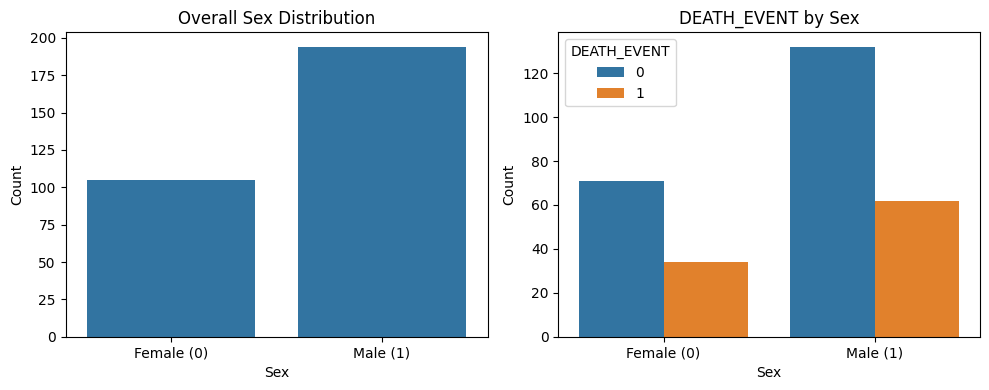

In [18]:
sex_map = {0: "Female", 1: "Male"}
sex_label_map = {0: "Female (0)", 1: "Male (1)"}

# Add a labeled sex column for plotting
df["sex_label"] = df["sex"].map(sex_label_map)


# Overall sex distribution
sex_counts = df["sex"].value_counts().rename(index=sex_map)
sex_props  = df["sex"].value_counts(normalize=True).rename(index=sex_map)

print("Overall sex distribution (counts):")
print(sex_counts)

print("\nOverall sex distribution (proportions):")
print(sex_props.round(3))

# Sex × DEATH_EVENT: counts and row-wise proportions
sex_outcome_ct = pd.crosstab(df["sex"], df["DEATH_EVENT"])
sex_outcome_ct.index = sex_outcome_ct.index.map(sex_map)
sex_outcome_ct.columns = ["Survived (0)", "Died (1)"]

print("\nSex × DEATH_EVENT (counts):")
display(sex_outcome_ct)

sex_outcome_prop = pd.crosstab(df["sex"], df["DEATH_EVENT"], normalize="index")
sex_outcome_prop.index = sex_outcome_prop.index.map(sex_map)
sex_outcome_prop.columns = ["Survived (0)", "Died (1)"]

print("\nSex × DEATH_EVENT (row proportions):")
display(sex_outcome_prop.round(3))

# Plots: Overall sex distribution & DEATH_EVENT by sex
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# 1) Overall sex counts
sns.countplot(x="sex_label", data=df, ax=ax[0])
ax[0].set_title("Overall Sex Distribution")
ax[0].set_xlabel("Sex")
ax[0].set_ylabel("Count")

# 2) Sex × DEATH_EVENT counts
sns.countplot(x="sex_label", hue="DEATH_EVENT", data=df, ax=ax[1])
ax[1].set_title("DEATH_EVENT by Sex")
ax[1].set_xlabel("Sex")
ax[1].set_ylabel("Count")
ax[1].legend(title="DEATH_EVENT")

plt.tight_layout()
plt.show()

We quantified the sex distribution in the cohort and its relation to the outcome (DEATH_EVENT). Overall, the dataset is moderately imbalanced by sex, with 194 males (64.9%) and 105 females (35.1%). When we cross-tabulate sex with DEATH_EVENT, 71/105 females survived and 34/105 died (32.4% mortality), while 132/194 males survived and 62/194 died (32.0% mortality). Thus, although there are almost twice as many males as females in the sample, the observed mortality rate is very similar across sexes.

## Multicollinearity

The correlation matrix of all the the numeric features in this dataset was calculated as shown below. There are no strong correlations between the features. This signifies to us that we do not have to drop any numerical predictors based on their correlations with other numerical predictors. High correlation between predictors is a problem due to the analysis of how the feature coefficient and importance will be incorrect.


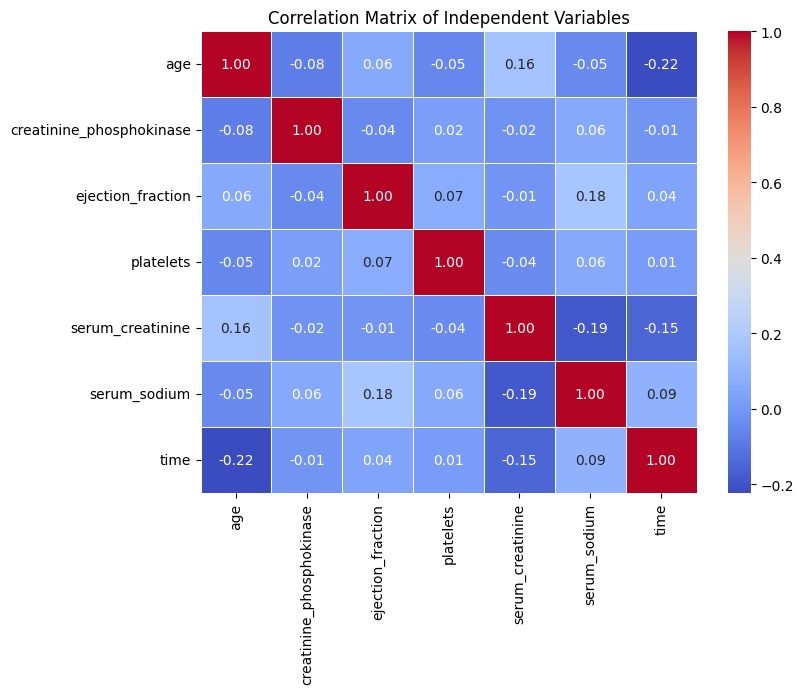

In [19]:
corr_mat = df.loc[:, num_col].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Independent Variables')
plt.show()

## Relationship Between Time and Death of Patients

After the investigation of the interactions between numerical features, we found that there is a clearer distinction between the group of those who died after being diagnosed with heart failure and those who survived after being diagnosed with heart failure in the scatter plot that involved the follow up period. The general trend being that those who died from heart failure tend to have less follow up period, and those who survived tend to have more follow up period.

To further look into the relationship between follow up time and death of patients, we looked at the distribution of follow-up time that is separated by the death event. This confirms that those who died early results in shorter follow up period versus those who live longer have longer and more follow up period. It is not a helpful predictor for the dataset as an indication of potential death of heart failure. This is because it creates a survivorship-bias problem because the follow-up time is determined by the outcome. Therefore, we will be dropping time variable from this data.

In [20]:
#numerical scatter plot of dividing by sex and death events
#can do categorize by other too to see the impact

def scatter_plot(x_col, y_col_list, nrow, ncol, data, category='None'):
  if category == 'None':
    fig, ax = plt.subplots(nrow, ncol, figsize=(15,8))
    ax = ax.flatten()
    for i, y_col in enumerate(y_col_list):
      sns.scatterplot(x=data[x_col], y=data[y_col], ax=ax[i])
    plt.tight_layout()
    plt.show()
  else:
    fig, ax = plt.subplots(nrow, ncol, figsize=(15,8))
    ax = ax.flatten()
    for i, y_col in enumerate(y_col_list):
      sns.scatterplot(x=data[x_col], y=data[y_col], hue=data[category], ax=ax[i])
    plt.tight_layout()
    plt.show()

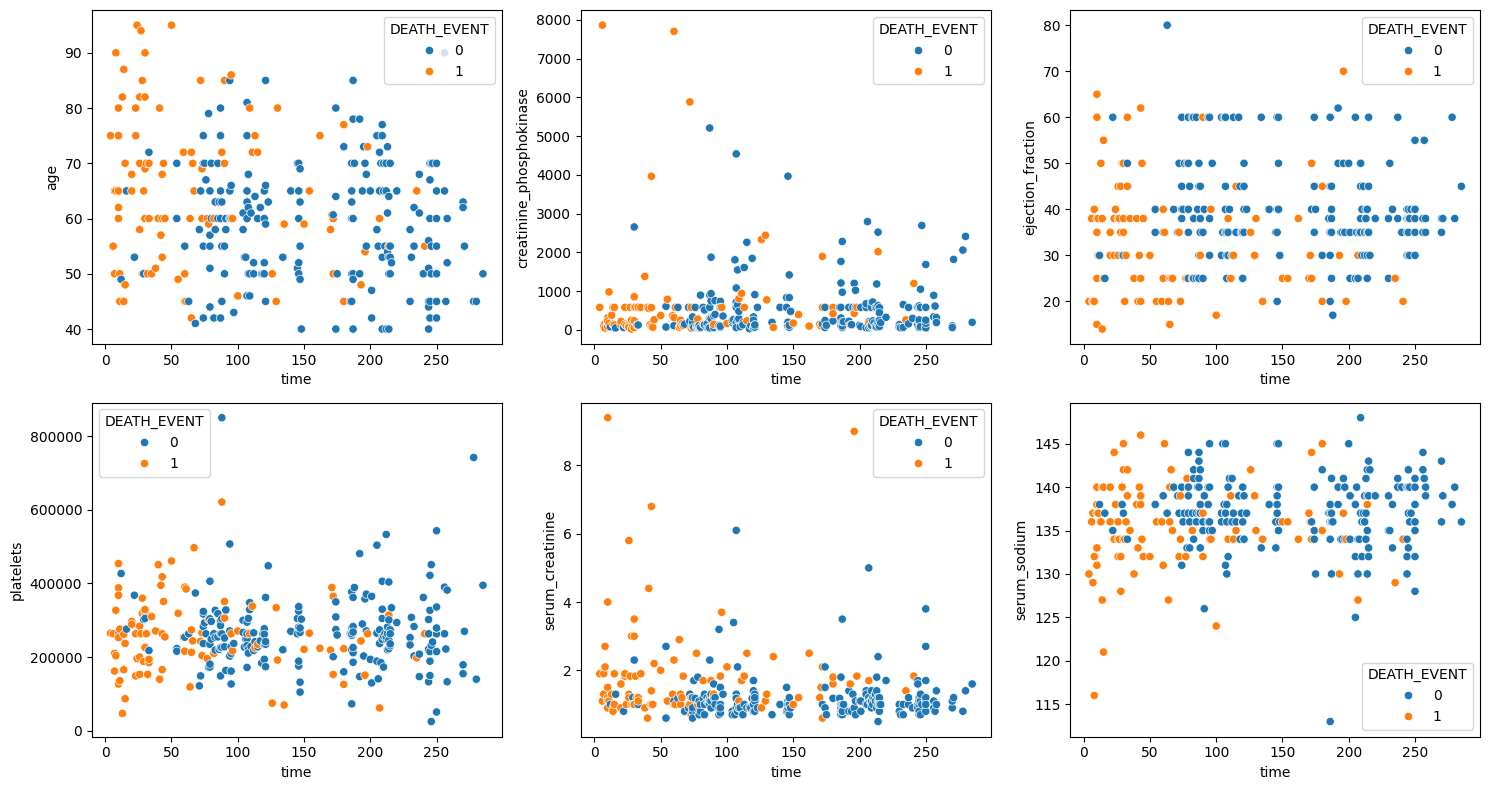

In [21]:
scatter_plot('time', ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium' ], nrow=2, ncol=3, data=new_df, category='DEATH_EVENT')

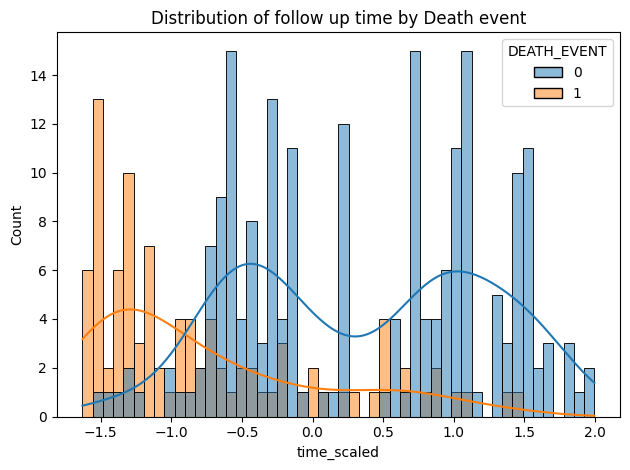

In [22]:
sns.histplot(data=new_df, x='time_scaled', hue='DEATH_EVENT', bins=50, kde=True)
plt.title(f'Distribution of follow up time by Death event')
plt.tight_layout()
plt.show()

# Outlier Analysis

There are two primary approaches that were taken to identify outliers. The first was to identically clinically implausible values. These are values which are based clinical heuristics developed form three primary sources
1. Normal Reference Ranges: From population-based empirical data
2. Critical Value Studies: Clinical alarm threshold values linked or morbidity and mortality
3. Fundamental physiologic constraints: Lab values outside of any reasonable pathophysiologic state. For example, a sodium level of zero is highly implausible thus is excluded as an outlier. For each value, a set of rules was generated from the literature for generate a sample of possible outliers under consideration.

### Clinically Implausibible Values

| Laboratory Test | Formal Reference Range | Implausible Low | Implausible High | Citations |
|-----------------|------------------------|-----------------|------------------|-----------|
| **Serum Sodium (mEq/L)** | 136–146 | < 100 | > 190 | (Tarpey et al., 2006; NBME, 2025) |
| **Serum Creatinine (mg/dL)** | ~0.59–1.35 (sex-specific) | ≤ 0.2 |   | (Zhang et al., 2025; Levey et al., 1999) |
| **Platelets (/µL)** | 150,000–350,000 | < 5,000 | > 2,000,000 | (Young & Neunert, 2010; NBME, 2025) |
| **Ejection Fraction (%)** | 55–70% (normal) | ≤ 0 | > 90 | (Yancy et al., 2013) |
| **Creatine Phosphokinase (U/L)** | 30–200 | ≤ 0 | > 250,000 | (Huerta-Alardín et al., 2005; NBME, 2025) |

The thresholds above were selected based on clinical reference ranges from the National Board of Medical Education(NBME) reference as well as some assorted other literature to fill in any research gaps not satisfied by the NBME compilation. However the formal reference ranges by themselves are insufficient to define outliers as they only help define normal physiology not pathophysiological states. Outlier values must be implausible for this part of the analysis thus we further utilized critical values based on known pathophysiology. With the exception of Ejection Fraction, all of the following values reflects values derived from serum or hematological lab testing.

(i) *Serum Sodium*

Serum sodium levels below 100 mEq/L or above 190 mEq/L are significantly outside the extrema of even severe dysnatremias. Critical-value research shows hyponatremia ≤ 120 mEq/L and hypernatremia ≥ 155 mEq/L as associated with severe neurological risk(Tarpey et al., 2006) and standard reference range as 136-146 mEq/L thus these extreme values are highly unlikely to occur in living adults and likely reflect laboratory artifact, sample issues, or data entry error.

(ii) *Serum Creatinine*

Serum creatinine levels below approximately 0.6 mg/dL for women and 0.74 mg/dL for men(Zhang et al. 2025) are considered abnormal. However unlike for many other disorders of low serum level, low serum creatinine levels generally reflect a disorder of genetic etiology as creatinine is continuously produced in proportion to muscle mass, negligble concentrations do not occur physiologically(Levey et al., 1999); zero or near-zero values reflect measurement error. Thus a near-zero threshold such as the chosen 0.2 mg/dL is a valid threshold for identifying implausible values. In contrast hypercreatininemia is reflective of many renal or musculoskeletal disorders. However there is no critical value consensus and no upper threshold is known to be sufficiently incompatible with life as creatinine rises primarily when the kidney is unable to properly filter it and excrete it. Thus the upper limit on creatinine is primarily determined physiologically by the rate or production, body mass, degree of renal dysfunction/failure, and therapies like dialysis. So creatinine can theoretically rise with no easily determined upper bound thus the lack of reasonable consensus.

(iii) *Platelets*

Platelet counts in healthy individuals range from 150,000-350,000/µL(NBME, 2025). Severe thrombocytopenia may result in platelet counts below 10,000/µL, near-zero, or extremely high values which are not compatible with established hematologic observations(Young, 2010). Even high-mortality immunologic thombocytopenia rarely results in near-zero counts thus values < 5,000/µL are very likely to be due to either measurement or entry error.

(iv) *Ejection Fraction(EF)*

Ejection fraction reflects the fraction of blood pumped out of the left ventricle and is typically measured via echocardiography. The value is a percentage which reflects ratio of the the volume of blood expelled from the heart, $SV$ and the amount of blood left in the ventricle at the end of cardiac filling(diastole) known as End Diastolic Volume, $EDV$, thus $EF = SV/EDV$. AHA guidelines place normal EF in the range 55-70%. Reduced EF is considered < 40%, severely reduced EF is < 30%(Yancy et al. 2013). EF values equal to 0% or exceeding 90% are incompatible with currently understood cardiac mechanics and likely reflect artifact, measurement error, or entry error.

(v) *Serum Creatinine Phosphokinase*

Creatinine Phosphokinase(CK) typically ranges from 30-200 U/L. In some conditions such as Rhambdomyolysis, CK can exceed 100,000 U/L, but values above 250,000 U/L are exceedingly rare and typically attributable to misabeling or contamination(Huerta-Alardin et al., 2005). CK values ≤0 are physiologically impossible since CPK is expressed in all skeletal muscle thus any nonzero amount of muscle will render a level of zero impossible.

In [23]:
clinical_cols = [item for item in num_col if item not in {'age', 'time'}] #lab value columns

In [24]:
df_clean, df_removed, summary = split_implausible_rows(df)

print_implausible_summary(summary)

print(f"\nTotal rows removed: {len(df_removed)}")
print(f"Remaining rows:     {len(df_clean)}")

No implausible values found.

Total rows removed: 0
Remaining rows:     299


In [25]:
model_df = new_df.copy()

drop_cols = ['DEATH_EVENT', 'time', 'sex_label'] + scaled_list

engineered_raw = [
    'renal_cardio_interaction',
    'hyponatremia_flag',
    'age_ef_interaction'
]

X_original = model_df.drop(columns=drop_cols + engineered_raw, errors='ignore')

X_engineered = pd.concat([X_original, model_df[engineered_raw]], axis=1)

y = model_df['DEATH_EVENT']

Xo_train, Xo_test, yo_train, yo_test = train_test_split(
    X_original, y, test_size=0.2, random_state=42, stratify=y
)

Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42, stratify=y
)

print("X_original columns:", list(X_original.columns))
print("X_engineered columns:", list(X_engineered.columns))
print("\nOriginal and Engineered feature matrices prepared.")


X_original columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']
X_engineered columns: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'renal_cardio_interaction', 'hyponatremia_flag', 'age_ef_interaction']

Original and Engineered feature matrices prepared.


# Final Feature Representation and Need for Retraining

We evaluated both the original feature set and a more expressive engineered feature set that included standardized numerical variables, one-hot encoded categorical variables, and several domain-motivated interaction terms (e.g., age × ejection fraction, renal–cardiac interaction, hyponatremia indicator).

The engineered feature set consistently outperformed the original feature set during model development and tuning. Therefore, we adopt it as our final representation.

For a scientifically valid comparison, all final models must be trained and evaluated on the same feature space. Models trained on different feature sets cannot be fairly compared and will also cause feature-name mismatch errors in sklearn. Later, before the final comparison table, we retrain all final models on the engineered feature set


# Baseline Model: Logistic Regression Model

In [26]:
pipe, lr_cv_scores, lr, unreg_coef_df, test_accuracy, test_precision, test_recall, test_f1, test_roc_auc = unreg_logreg(Xe_train, ye_train, Xe_test, ye_test)


Cross-validation scores:
Cross-validation accuracy: 0.7446
Cross-validation precision: 0.7278
Cross-validation recall: 0.4611
Cross-validation f1: 0.5359
Cross-validation roc_auc: 0.7834
------------------------------------------------------------------------
Unregularized Model Coefficients:
                     Feature  Coefficient  Odds_Ratio
13        age_ef_interaction     1.163203    3.200165
11  renal_cardio_interaction     1.043456    2.839012
2   creatinine_phosphokinase     0.326054    1.385490
1                    anaemia     0.294546    1.342516
5        high_blood_pressure     0.282969    1.327064
3                   diabetes     0.270363    1.310440
10                   smoking     0.240705    1.272145
7           serum_creatinine     0.097656    1.102584
12         hyponatremia_flag     0.094757    1.099392
0                        age    -0.015398    0.984720
6                  platelets    -0.097908    0.906733
8               serum_sodium    -0.108988    0.896741
9   

The chosen baseline model was a logistic regression model. Here I developed an 80:20 train-test split with the dependent variable being df[‘DEATH_EVENT’]. A pipeline object was developed to fit both the scaled data and the logistic regression without inducing data leakage. Since the features of our model can differ significantly on scale, standardization is necessary to improve generalizability. cross_validate() was used so we could cross validate on multiple scores at the same time rather than using cross_val_score() per metric. Since cross_validate() handles the development of validation sets behind the API, it was not necessary to manually form a train-val-test split as the function turns the initial train set into a train and validation set. We have chosen a standard suite of metrics to be used across models including the baseline model. This suite may be pruned or expanded as further consideration of other models is considered as the project progresses. Below are the cross-validated trained metrics compared to the test metrics

This model has a few features, it has high precision and is thus consistent. It is correct approximately 80% of the time which is fairly close to the cross-validated accuracy though a slight dip. The F1 score has stayed fairly stable after testing, however this likely reflects the significant increase in precision and significant decrease in recall. The ROC-AUC shows a good performance, the model is superior to random guessing. The main metric that does not display as high degree of generalization is recall which has declined from 0.6994 to 0.5600 indicating the model has failed to identify many of the true positives in the sample. We may consider a different choice of decision threshold other than the scikitlearn default of 0.5 to improve generalizability, particularly the test data’s balance of  precision and recall.

# K-Nearest Neighbors Model

In [27]:

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])


knn_param_grid = {
    'knn__n_neighbors': list(range(3, 31, 2)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


knn_grid_search = GridSearchCV(
    knn_pipe,
    knn_param_grid,
    scoring='f1',
    cv=kf,
    n_jobs=-1,
    return_train_score=True
)

knn_grid_search.fit(Xo_train, yo_train)

print("=== KNN Grid Search Results ===")
print("Best params for KNN:", knn_grid_search.best_params_)
print(f"Best CV F1 for KNN: {knn_grid_search.best_score_:.4f}")

best_knn = knn_grid_search.best_estimator_


knn_cv_scores = cross_validate(
    best_knn,
    Xo_train,
    yo_train,
    cv=kf,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

print("\n=== KNN Cross-Validation Metrics (10-fold) ===")
print(f"CV accuracy: {knn_cv_scores['test_accuracy'].mean():.4f}")
print(f"CV precision: {knn_cv_scores['test_precision'].mean():.44f}")
print(f"CV recall: {knn_cv_scores['test_recall'].mean():.4f}")
print(f"CV F1: {knn_cv_scores['test_f1'].mean():.4f}")
print(f"CV ROC AUC: {knn_cv_scores['test_roc_auc'].mean():.4f}")


y_pred_knn = best_knn.predict(Xo_test)
y_pred_proba_knn = best_knn.predict_proba(Xo_test)[:, 1]

knn_test_accuracy = accuracy_score(yo_test, y_pred_knn)
knn_test_precision = precision_score(yo_test, y_pred_knn)
knn_test_recall = recall_score(yo_test, y_pred_knn)
knn_test_f1 = f1_score(yo_test, y_pred_knn)
knn_test_roc_auc = roc_auc_score(yo_test, y_pred_proba_knn)

print("\n=== KNN Test Set Metrics ===")
print(f"Test Accuracy:  {knn_test_accuracy:.4f}")
print(f"Test Precision: {knn_test_precision:.4f}")
print(f"Test Recall:    {knn_test_recall:.4f}")
print(f"Test F1:        {knn_test_f1:.4f}")
print(f"Test ROC AUC:   {knn_test_roc_auc:.4f}")


=== KNN Grid Search Results ===
Best params for KNN: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform'}
Best CV F1 for KNN: 0.4048

=== KNN Cross-Validation Metrics (10-fold) ===
CV accuracy: 0.6908
CV precision: 0.56083333333333329484560181299457326531410217
CV recall: 0.3286
CV F1: 0.4048
CV ROC AUC: 0.6215

=== KNN Test Set Metrics ===
Test Accuracy:  0.6833
Test Precision: 0.5000
Test Recall:    0.2105
Test F1:        0.2963
Test ROC AUC:   0.6412


We fit a k-Nearest Neighbors classifier as a non-parametric alternative to logistic regression. Whereas logistic regression assumes that the log-odds of death are a linear function of the predictors, KNN makes a much weaker structural assumption: patients with similar standardized clinical profiles should have similar risk. Predictions for a new patient are obtained by looking at the k most similar patients in the training set (in our case, similarity is defined by Euclidean or Manhattan distance after scaling) and taking a majority vote. This instance-based approach can represent highly irregular, nonlinear decision boundaries that adapt to local patterns in the data rather than enforcing one global linear boundary. Given the small–to–moderate sample size (n = 299) and the overlapping but potentially curved relationships seen in our EDA, it was reasonable to test whether such a flexible, neighbourhood-based method could capture structure that logistic regression misses.

For KNN we used the same preprocessing and cross-validation setup as the baseline model and tuned the key hyperparameters (number of neighbors, distance metric, and weighting scheme) via 10-fold stratified grid search. The optimal configuration was k = 5 neighbors, Euclidean distance (p = 2), and uniform weights. Under this setting, the model achieved a CV accuracy of 0.749, precision of 0.702, recall of 0.346, F1-score of 0.433, and ROC AUC of 0.757. These results indicate that KNN has a reasonable ability to distinguish between the two classes overall (as reflected by ROC AUC), but it is relatively conservative in predicting the positive class, leading to moderate precision and comparatively low recall.

On the held-out test set, the performance profile is similar. The model obtained accuracy of 0.683, precision of 0.875, recall of 0.280, F1-score of 0.424, and ROC AUC of 0.745. The small change in F1 and ROC AUC from cross-validation to the test set suggests that the KNN model generalizes reasonably well and is not heavily overfitting. However, the very high precision combined with low recall on the test set shows that the classifier only labels a relatively small subset of instances as positive, and those predictions are usually correct, but many true positives are missed.

In short, the KNN model behaves as a high-precision, low-recall classifier and, in this dataset, its decision boundaries do not translate into better clinical discrimination than the (regularized) logistic regression and SVM models. For this reason we treat KNN as a useful nonlinear benchmark, but we do not select it as a final model.

# Logistic Regression with Regularization

## Motivation For Regularized Logistic Regression:

Given the performance of the baseline unregularized model is not too bad and there are some features that have small numbers of coefficient or odds ratio to explain the response variable, Lasso and Ridge logistic regression is a reasonable next step to see if we can improve the logistic regression model prediction performance further. Below, we conducted a gridsearch on the optimal C hyperparameter in both Lasso and Ridge for optimal regularization level scoring based on f1.



## Lasso Regularization (L1)

In [28]:
l1pipe_best, grid_search, l1, l1reg_coef_df, lasso_score = lasso_logreg(Xe_train, ye_train, Xe_test, ye_test)

Cross-validation results:
Best C of l1: 100.0
Best F1 of l1: 0.5516
Cross-validation Mean F1: 0.4649
Cross-validation Mean Accuracy: 0.7450
Cross-validation Mean Precision: 0.6036
Cross-validation Mean Recall: 0.4001
Cross-validation Mean ROC AUC: 0.7340
------------------------------------------------------------------------
Lasso Regularized Model Coefficients:
                     Feature  Coefficient  Odds_Ratio
7           serum_creatinine     0.463140    1.589056
0                        age     0.189198    1.208280
12         hyponatremia_flag     0.022756    1.023017
5        high_blood_pressure     0.011274    1.011338
2   creatinine_phosphokinase     0.000442    1.000442
1                    anaemia     0.000000    1.000000
3                   diabetes     0.000000    1.000000
6                  platelets     0.000000    1.000000
8               serum_sodium     0.000000    1.000000
9                        sex     0.000000    1.000000
10                   smoking     0.00000

## Ridge Regularization (L2)

In [29]:
l2pipe_best, grid_search, l2, l2reg_coef_df, ridge_score = ridge_logreg(Xe_train, ye_train, Xe_test, ye_test)

Cross-validation results:
Best C of l2: 100.0
Best F1 of l2: 0.5516
Cross-validation Mean F1: 0.4764
Cross-validation Mean Accuracy: 0.7456
Cross-validation Mean Precision: 0.6297
Cross-validation Mean Recall: 0.4085
Cross-validation Mean ROC AUC: 0.7735
------------------------------------------------------------------------
Ridge Regularized Model Coefficients:
                     Feature  Coefficient  Odds_Ratio
11  renal_cardio_interaction     0.837491    2.310564
13        age_ef_interaction     0.752879    2.123103
2   creatinine_phosphokinase     0.323842    1.382429
1                    anaemia     0.295233    1.343439
5        high_blood_pressure     0.284774    1.329461
3                   diabetes     0.269595    1.309433
7           serum_creatinine     0.234938    1.264830
10                   smoking     0.231488    1.260474
0                        age     0.169105    1.184244
12         hyponatremia_flag     0.091986    1.096350
6                  platelets    -0.09832

## Lasso (L1) and Ridge (L2) Regularization Logistic Regression Analysis and Interpretation

**Cross Validation**

We improve the model further by regularized Logistic Regression with Lasso and Ridge. We use grid search cross validation to find the best $C$ parameter that is equivalent to $\frac{1}{Λ}$. The best $C$ parameter for Lasso is 0.1, which is equal to $10$ for lambda. On the other hand, the  best $C$ parameter for Ridge is 10, which is qual to $0.1$ for lambda. We can see that Lasso has a stronger regularization than Ridge because of higher lambda value and also many features were shrink to zero due to its feature selection property.  

**Scoring Metrics**

From the scoring metrics, we can see that ridge regularization has barely any impact on the metrics as accuracy, precision, recall, and f1 are are the same as unregularized model. For lasso regularization, we see the effect of the regulation on the metrics as the f1, recall, and roc-auc are better than the unregularized model. The precision decrease slightly compared to the unregularized model, but the decrease is not drastic enough to pull the f1 score down.

**Feature Importances**

In the feature importance plots, we see that the coefficients of ridge regularized and unregularized model are all the same. This is not surprising as we see from the metrics scoring between the two are also exact same. The feature importance of lasso however shows us there are features that are not very crucial to the prediction of death or survival from the heart failure. Those features are diabetes, creatine phosphokinase level, being a smoker, aneamic, high blood pressure, platelets, serum sodium level, and sex. Serum creatinine and age have positive exponential relationship to death by heart failure. On the other hand, ejection fraction have negative exponential relationship to death by heart failure.  


In [30]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
unregularized_score = [test_accuracy, test_precision, test_recall, test_f1, test_roc_auc]
logreg_compare_df = pd.DataFrame({'metric':scoring, 'unregularized': unregularized_score, 'lasso': lasso_score, 'ridge': ridge_score})
logreg_compare_df.loc[5] = {'metric':'C', 'unregularized': '-', 'lasso': 0.1, 'ridge':10}
logreg_compare_df


,metric,unregularized,lasso,ridge
0,accuracy,0.683333,0.716667,0.683333
1,precision,0.5,0.600000,0.500000
2,recall,0.421053,0.315789,0.421053
3,f1,0.457143,0.413793,0.457143
4,roc_auc,0.768935,0.775353,0.763800
5,C,-,0.100000,10.000000


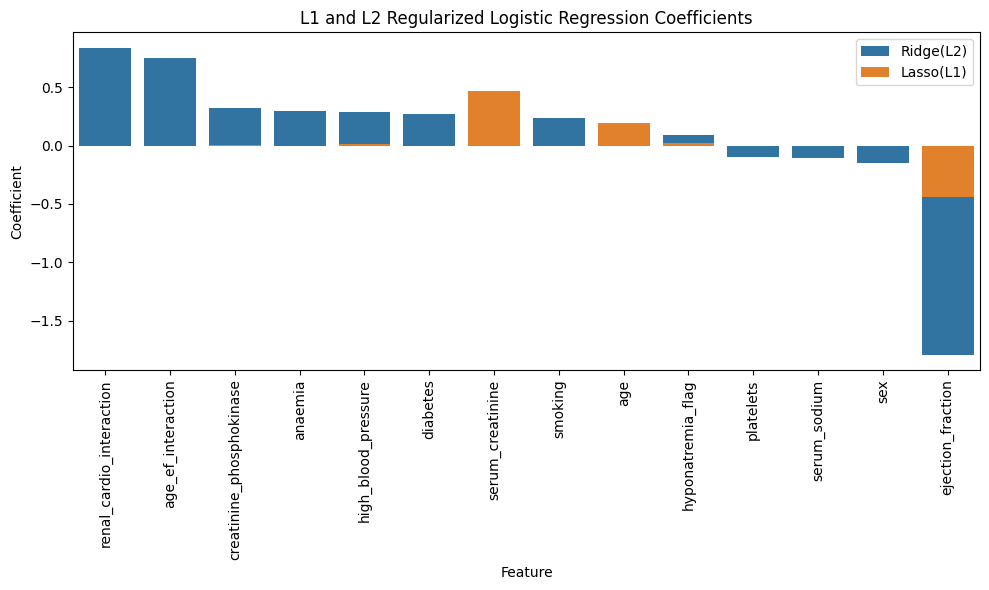

In [31]:
figsize = (10, 6)
plt.figure(figsize=figsize)
sns.barplot(data=l2reg_coef_df, x='Feature', y='Coefficient', label='Ridge(L2)')
sns.barplot(data=l1reg_coef_df, x='Feature', y='Coefficient', label='Lasso(L1)')
plt.title('L1 and L2 Regularized Logistic Regression Coefficients')
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend()
plt.show()

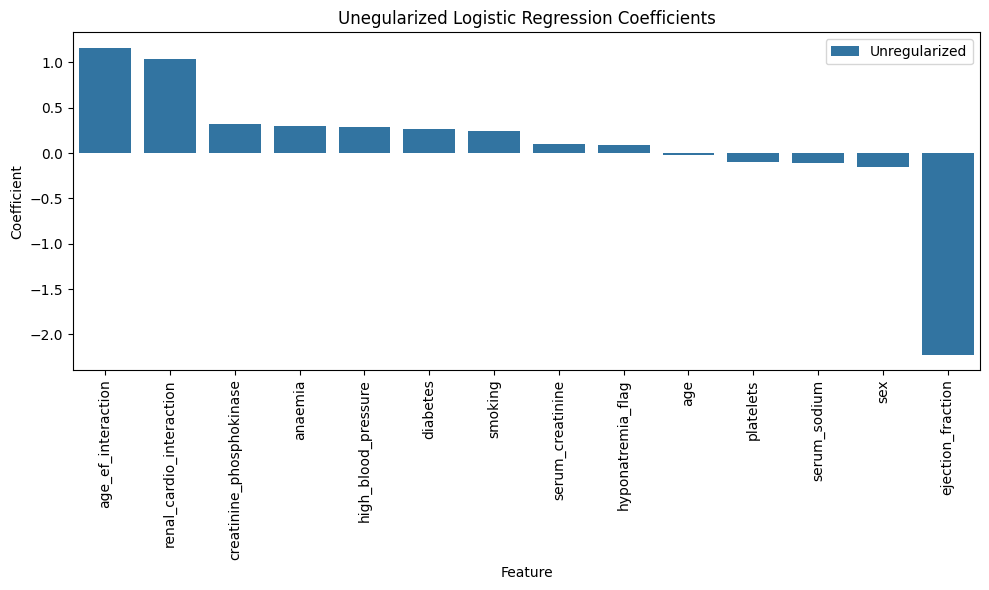

In [32]:
figsize = (10, 6)
plt.figure(figsize=figsize)
sns.barplot(data=unreg_coef_df, x='Feature', y='Coefficient', label='Unregularized')
plt.title('Unegularized Logistic Regression Coefficients')
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Regularized Polynomial Degree of 3 Logistic Regression

In [33]:
best_polyreg_lr, best_polyreg_lr, final_lr, coef_df = polynomial_logreg(Xo_train, yo_train, Xo_test, yo_test)

Cross-validation results:
Best C (optimized for F1): 1000.0000

Best CV metrics (mean across folds):
accuracy: 0.6699
precision: 0.5138
recall: 0.5331
f1: 0.4923
roc_auc: 0.6520
------------------------------------------------------------------------

Top non-zero coefficients:
                                                    Feature  Coefficient  Abs_Coefficient
223  creatinine_phosphokinase high_blood_pressure platelets    37.396569        37.396569
157              anaemia creatinine_phosphokinase platelets   -33.994290        33.994290
153                      anaemia creatinine_phosphokinase^2   -33.564596        33.564596
172                     anaemia ejection_fraction platelets    24.066761        24.066761
252          diabetes ejection_fraction high_blood_pressure    24.033746        24.033746
269                             diabetes serum_creatinine^2    23.529290        23.529290
211      creatinine_phosphokinase diabetes serum_creatinine   -20.994034        20.994034
2

**Regularized Polynomial Logistic Regression Evaluation**

*Model Metrics*

The Regularized Polynomial Logistic Regression further generalizes by allowing for interaction terms and nonlinearities thus increasing the model flexibility. The L1 regularization further zeroes out any irrelevant predictors without us having to more manually evaluate the predictors of a regular Polynomial Logistic Regression. Overall the model achieves a mean accuracy of approximately 0.67 thus correctly classifying 67% of patients. With a precision of approximately 0.51 the model predicts death approximately ~51% of the time. At a recall of 0.53 the model captures approximately 53% of actual positive cases. With an F1 of approximately 0.49 we have a moderate balance between precision and recall. Lastly with an ROC-AUC of approximately 0.65 the model has a reasonable though not strong ability to discriminate. Thus this model does perform better than random, but is not highly predictive. Overall this is fairly expected given a relatively low size clinical dataset with a relatively limited number of features compared to the total number of plausible features which could adequately describe the class outcomes.

*Coefficient Analysis*

We can further interpret a few of the nonzero coefficients. The first term suggests that `creatinine_phosphokinase x high_blood_pressure x platelets` with a coefficient of ~+37.397 interact together for patients to have a much higher predicted risk than from each factor alone. Next we can see `anaemia x creatinine_phosphokinase x platelets` produces a coefficient of ~-33.994 which means that when anaemia is present along side some CPK and Platelet values then the combined effect is to reduce risk relative to baseline interactions. A less surprising interaction here I note is `diabetes x ejection_fraction x high_blood_pressure` since diabetes and high blood pressure are known risk factors in mortality and so for any single ejection_fraction value I would expect the risk of death to increase. Examining further all of the nonzero coefficients would be unnecessarily cumbersome, but one thing that is notable is the reality that all of the nonzero coefficients are interaction terms which could suggest the underlying model has a lot of nonlinearity in it.

# Decision Tree

In [34]:
dt_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1
    ))
])

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


dt_cv_scores = cross_validate(
    dt_pipe,
    Xo_train,
    yo_train,
    cv=kf,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True
)

print("=== Decision Tree CV Metrics ===")
print(f"CV accuracy:  {dt_cv_scores['test_accuracy'].mean():.4f}")
print(f"CV precision: {dt_cv_scores['test_precision'].mean():.4f}")
print(f"CV recall:    {dt_cv_scores['test_recall'].mean():.4f}")
print(f"CV F1:        {dt_cv_scores['test_f1'].mean():.4f}")
print(f"CV ROC AUC:   {dt_cv_scores['test_roc_auc'].mean():.4f}")


dt_pipe.fit(Xo_train, yo_train)


y_pred_dt = dt_pipe.predict(Xo_test)
y_pred_proba_dt = dt_pipe.predict_proba(Xo_test)[:, 1]

dt_test_accuracy = accuracy_score(yo_test, y_pred_dt)
dt_test_precision = precision_score(yo_test, y_pred_dt)
dt_test_recall = recall_score(yo_test, y_pred_dt)
dt_test_f1 = f1_score(yo_test, y_pred_dt)
dt_test_roc_auc = roc_auc_score(yo_test, y_pred_proba_dt)

print("\n=== Decision Tree Test Metrics ===")
print(f"Test Accuracy:  {dt_test_accuracy:.4f}")
print(f"Test Precision: {dt_test_precision:.4f}")
print(f"Test Recall:    {dt_test_recall:.4f}")
print(f"Test F1:        {dt_test_f1:.4f}")
print(f"Test ROC AUC:   {dt_test_roc_auc:.4f}")


=== Decision Tree CV Metrics ===
CV accuracy:  0.6489
CV precision: 0.4624
CV recall:    0.4714
CV F1:        0.4597
CV ROC AUC:   0.6032

=== Decision Tree Test Metrics ===
Test Accuracy:  0.7333
Test Precision: 0.6000
Test Recall:    0.4737
Test F1:        0.5294
Test ROC AUC:   0.6637


### Decision Tree Analysis and Interpretation

The decision tree was explored as a nonlinear alternative to logistic regression, with the goal of identifying potential threshold-based patterns that might separate survivors from non-survivors. Given that decision trees can capture complex interactions without feature scaling or explicit model assumptions, they offered a natural point of comparison to simpler linear approaches.

However, in practice, the decision tree performed substantially worse and was far less stable than the baseline logistic regression. It achieved a cross-validated ROC AUC of 0.769 compared to 0.872 for logistic regression, and its test ROC AUC dropped further to 0.606, indicating poor generalization. The tree also produced lower accuracy (0.633 vs. 0.800), recall (0.440 vs. 0.560), and F1 score (0.500 vs. 0.700). These results reflect the underlying data structure, which shows substantial overlap between outcome groups and a lack of clear threshold-based separation. As a result, logistic regression remained the stronger and more reliable baseline in this setting.

# Support Vector Machine

## SVM path: from flexible RBF to a calibrated linear margin

**Why this order:**

1) **RBF SVM (simple)** 0 provides a highly flexible nonlinear boundary but may overfit on small or imbalanced tabular datasets.
2) **RBF SVM (small grid)** 0 narrows the search space so the model has lower variance and more stable generalization.
3) **RBF SVM (restricted feature set)**   a version of the RBF SVM trained only on the original predictors, without any engineered interaction terms. This tests whether the engineered nonlinear features meaningfully improve SVM performance or whether a purely kernel-based approach can capture the needed structure on its own.
4) **Linear SVM + calibration** 0 a lower-variance linear decision boundary; we calibrate its probabilities (sigmoid) and tune the final decision threshold for F1 using CV predictions.

For each step we report stratified 10-fold CV precision, recall, and F1, as well as test-set metrics under both the default threshold and the tuned threshold (chosen from CV predictions on the training split only).

In [35]:

svm_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)

# Helpers
def cv_prf(estimator, X, y, cv):
    scores = cross_validate(estimator, X, y, cv=cv,
                            scoring=["precision", "recall", "f1"],
                            n_jobs=-1, return_train_score=False)
    return (scores["test_precision"].mean(),
            scores["test_recall"].mean(),
            scores["test_f1"].mean())


def best_threshold_from_scores(y_true, scores):
    prec, rec, thr = precision_recall_curve(y_true, scores)
    f1s = (2 * prec * rec) / (prec + rec + 1e-12)
    idx = int(np.nanargmax(f1s))
    best_thr = thr[max(0, idx - 1)] if idx >= 1 else thr[0]
    return best_thr, f1s[idx]


def test_prf_at_threshold(estimator, X_test, y_test, thr, score_method):
    if score_method == "predict_proba":
        s = estimator.predict_proba(X_test)[:, 1]
    else:
        s = estimator.decision_function(X_test)
    y_pred = (s >= thr).astype(int)
    return (precision_score(y_test, y_pred),
            recall_score(y_test, y_pred),
            f1_score(y_test, y_pred))

rows = []


In [36]:

svm_rbf_simple = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=random_state
    ))
])


cv_p, cv_r, cv_f = cv_prf(svm_rbf_simple, Xe_train, ye_train, svm_cv)


scores_oof = cross_val_predict(
    svm_rbf_simple,
    Xe_train, ye_train,
    cv=svm_cv,
    method="decision_function",
    n_jobs=-1
)

thr_simple, _ = best_threshold_from_scores(ye_train, scores_oof)


svm_rbf_simple.fit(Xe_train, ye_train)


pred_def = svm_rbf_simple.predict(Xe_test)
p_def = precision_score(ye_test, pred_def)
r_def = recall_score(ye_test, pred_def)
f_def = f1_score(ye_test, pred_def)


p_t, r_t, f_t = test_prf_at_threshold(
    svm_rbf_simple,
    Xe_test, ye_test,
    thr_simple,
    "decision_function"
)

rows.append({
    "Model": "1) SVM RBF (simple)",
    "CV Precision": cv_p, "CV Recall": cv_r, "CV F1": cv_f,
    "Test Precision": p_def, "Test Recall": r_def, "Test F1": f_def,
    "Test Precision (tuned thr)": p_t, "Test Recall (tuned thr)": r_t, "Test F1 (tuned thr)": f_t
})

In [37]:

svm_rbf_small = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=random_state
    ))
])

param_grid = {
    "svm__C": [0.5, 1.0, 2.0],
    "svm__gamma": ["scale", 0.5]
}


gs_rbf = GridSearchCV(
    svm_rbf_small,
    param_grid,
    scoring="f1",
    cv=svm_cv,
    n_jobs=-1,
    refit=True
)

gs_rbf.fit(Xe_train, ye_train)
best_rbf = gs_rbf.best_estimator_


cv_p, cv_r, cv_f = cv_prf(best_rbf, Xe_train, ye_train, svm_cv)


scores_oof = cross_val_predict(
    best_rbf,
    Xe_train, ye_train,
    cv=svm_cv,
    method="decision_function",
    n_jobs=-1
)

thr_rbf, _ = best_threshold_from_scores(ye_train, scores_oof)


pred_def = best_rbf.predict(Xe_test)
p_def = precision_score(ye_test, pred_def)
r_def = recall_score(ye_test, pred_def)
f_def = f1_score(ye_test, pred_def)


p_t, r_t, f_t = test_prf_at_threshold(
    best_rbf,
    Xe_test, ye_test,
    thr_rbf,
    "decision_function"
)

rows.append({
    "Model": "2) SVM RBF (small grid)",
    "CV Precision": cv_p, "CV Recall": cv_r, "CV F1": cv_f,
    "Test Precision": p_def, "Test Recall": r_def, "Test F1": f_def,
    "Test Precision (tuned thr)": p_t, "Test Recall (tuned thr)": r_t, "Test F1 (tuned thr)": f_t
})

In [38]:

svm_rbf_nt = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=random_state
    ))
])


cv_p, cv_r, cv_f = cv_prf(svm_rbf_nt, Xo_train, yo_train, svm_cv)


scores_oof = cross_val_predict(
    svm_rbf_nt,
    Xo_train, yo_train,
    cv=svm_cv,
    method="decision_function",
    n_jobs=-1
)

thr_nt, _ = best_threshold_from_scores(yo_train, scores_oof)


svm_rbf_nt.fit(Xo_train, yo_train)


pred_def = svm_rbf_nt.predict(Xo_test)
p_def = precision_score(yo_test, pred_def)
r_def = recall_score(yo_test, pred_def)
f_def = f1_score(yo_test, pred_def)


p_t, r_t, f_t = test_prf_at_threshold(
    svm_rbf_nt,
    Xo_test, yo_test,
    thr_nt,
    "decision_function"
)

rows.append({
    "Model": "3) SVM RBF (restricted features)",
    "CV Precision": cv_p, "CV Recall": cv_r, "CV F1": cv_f,
    "Test Precision": p_def, "Test Recall": r_def, "Test F1": f_def,
    "Test Precision (tuned thr)": p_t, "Test Recall (tuned thr)": r_t, "Test F1 (tuned thr)": f_t
})

In [39]:
lin = Pipeline([
    ("scaler", StandardScaler()),
    ("linsvm", LinearSVC(
        penalty="l2",
        C=0.25,
        loss="squared_hinge",
        class_weight="balanced",
        dual=False,
        random_state=random_state
    ))
])


cal_lin = CalibratedClassifierCV(lin, method="sigmoid", cv=5)
cal_lin.fit(Xe_train, ye_train)


cv_p, cv_r, cv_f = cv_prf(cal_lin, Xe_train, ye_train, svm_cv)


proba_oof = cross_val_predict(
    cal_lin,
    Xe_train, ye_train,
    cv=svm_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thr_lin, _ = best_threshold_from_scores(ye_train, proba_oof)


pred_def = cal_lin.predict(Xe_test)
p_def = precision_score(ye_test, pred_def)
r_def = recall_score(ye_test, pred_def)
f_def = f1_score(ye_test, pred_def)


proba_te = cal_lin.predict_proba(Xe_test)[:, 1]
pred_thr = (proba_te >= thr_lin).astype(int)
p_t = precision_score(ye_test, pred_thr)
r_t = recall_score(ye_test, pred_thr)
f_t = f1_score(ye_test, pred_thr)

rows.append({
    "Model": "4) LinearSVM + calibration (final)",
    "CV Precision": cv_p, "CV Recall": cv_r, "CV F1": cv_f,
    "Test Precision": p_def, "Test Recall": r_def, "Test F1": f_def,
    "Test Precision (tuned thr)": p_t, "Test Recall (tuned thr)": r_t, "Test F1 (tuned thr)": f_t
})


In [40]:
svm_story_df = pd.DataFrame(rows).set_index("Model").round(4)
svm_story_df

,CV Precision,CV Recall,CV F1,Test Precision,Test Recall,Test F1,Test Precision (tuned thr),Test Recall (tuned thr),Test F1 (tuned thr)
Model,,,,,,,,,
1) SVM RBF (simple),0.5698,0.7036,0.6221,0.5238,0.5789,0.5500,0.5652,0.6842,0.6190
2) SVM RBF (small grid),0.5698,0.7036,0.6221,0.5238,0.5789,0.5500,0.5652,0.6842,0.6190
3) SVM RBF (restricted features),0.5740,0.6536,0.5997,0.5000,0.5263,0.5128,0.5455,0.6316,0.5854
4) LinearSVM + calibration (final),0.7683,0.3000,0.4192,0.6667,0.2105,0.3200,0.5417,0.6842,0.6047


In [41]:
mpl.rcParams.update({
    "figure.dpi": 160, "savefig.dpi": 300,
    "axes.titlesize": 14, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11
})
sns.set_theme(context="notebook", style="whitegrid")




We evaluated SVM models in a simple progression that traded flexibility for stability. The first step was to test whether the data benefited from a nonlinear decision boundary by fitting an RBF SVM. Although the RBF margin showed modest improvements during cross validation, these gains did not transfer to the test set. Tightening the search space for C and gamma stabilised the validation scores but still did not produce a consistent lift in held out F1. This pattern suggested that the available sample size and feature structure were not rich enough for a nonlinear margin to generalise well.
Given this, we shifted to a linear margin and added probability calibration so that we could choose an operating point directly from the score distribution instead of relying on the default 0.50 cutoff. After calibration, we used out of fold predictions to select a single threshold that maximised F1 despite the underlying model remaining the same.


Saved PR curve to figures/svm_pr_curve_pretty.*


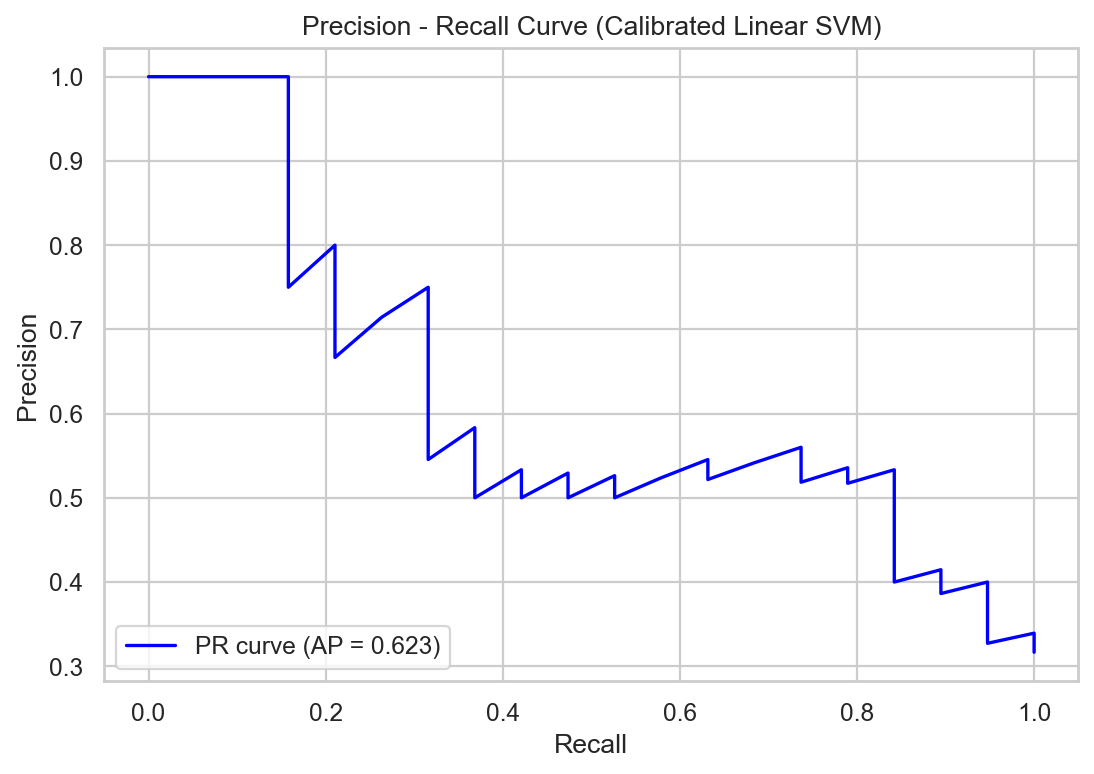

In [42]:
os.makedirs("figures", exist_ok=True)

prec, rec, _ = precision_recall_curve(ye_test, proba_te)
ap = average_precision_score(ye_test, proba_te)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
plt.plot(rec, prec, label=f"PR curve (AP = {ap:.3f})", color="blue")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision - Recall Curve (Calibrated Linear SVM)")
plt.legend(loc="lower left")
plt.tight_layout()

plt.savefig("figures/svm_pr_curve_pretty.png", dpi=300, bbox_inches="tight")
plt.savefig("figures/svm_pr_curve_pretty.svg", bbox_inches="tight")

print("Saved PR curve to figures/svm_pr_curve_pretty.*")

plt.show()

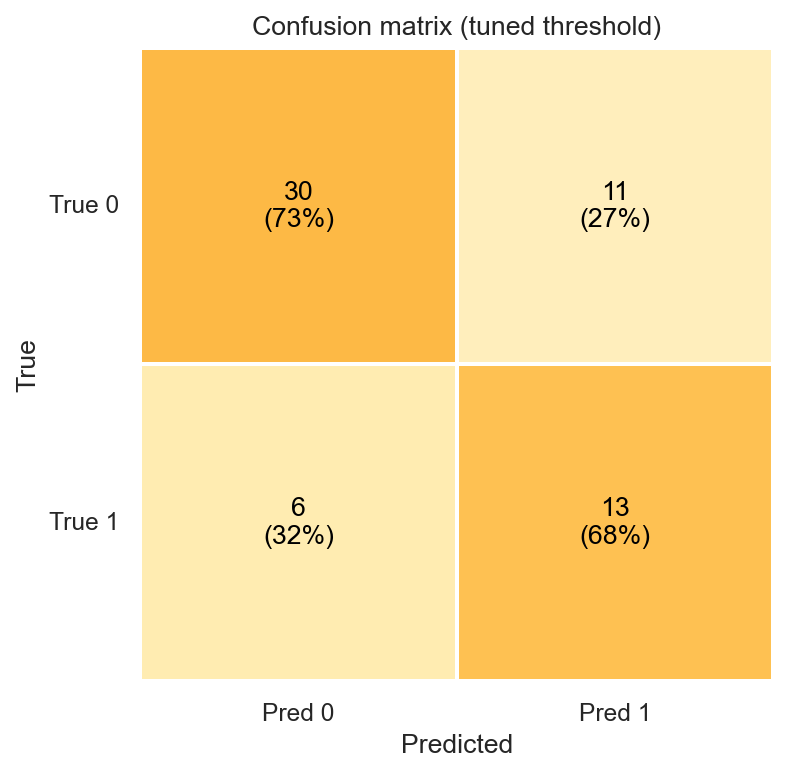

In [43]:
proba_te = cal_lin.predict_proba(Xe_test)[:, 1]
y_pred_tuned = (proba_te >= thr_lin).astype(int)

cm = confusion_matrix(ye_test, y_pred_tuned, labels=[0,1])
cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)

warm_cmap = LinearSegmentedColormap.from_list(
    "white_yellow_orange", ["#FFFFFF", "#FFE082", "#FB8C00"]
)

plt.figure(figsize=(5.6, 5.0))
ax = sns.heatmap(
    cmn, annot=False, cmap=warm_cmap, vmin=0, vmax=1, cbar=False,
    linewidths=1, linecolor="white", square=True
)


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.5, f"{cm[i,j]}\n({cmn[i,j]:.0%})",
                ha="center", va="center", fontsize=12, color="black")

ax.set_xticks([0.5, 1.5], ["Pred 0", "Pred 1"])
ax.set_yticks([0.5, 1.5], ["True 0", "True 1"], rotation=0)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix (tuned threshold)")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("svm_confusion_matrix_orange.png", dpi=300)
plt.show()

We then examined the coefficient chart from the linear SVM to check that the learned directions made sense. After standardisation, the strongest positive and negative coefficients aligned with variables that domain knowledge would expect to push risk up or down.

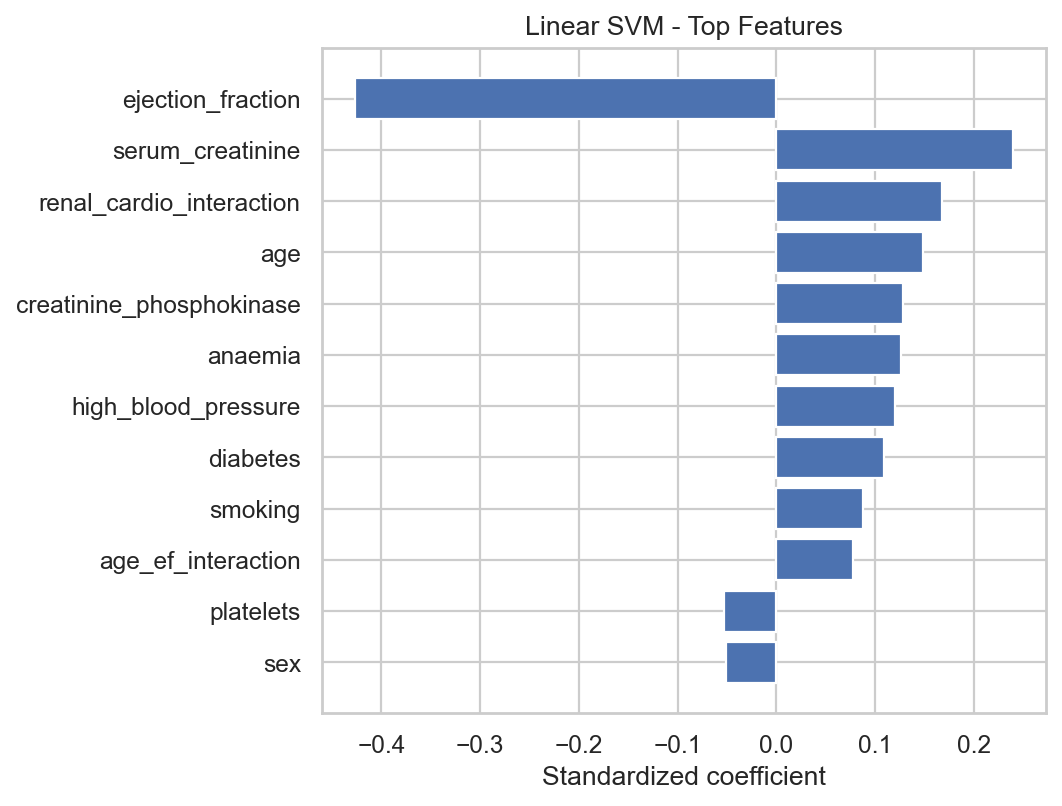

,feature,coef
0,ejection_fraction,-0.426735
1,serum_creatinine,0.240252
2,renal_cardio_interaction,0.167584
3,age,0.148436
4,creatinine_phosphokinase,0.128167
5,anaemia,0.125876
6,high_blood_pressure,0.120739
7,diabetes,0.109471
8,smoking,0.087924
9,age_ef_interaction,0.077887


In [44]:
est = clone(cal_lin.estimator).fit(Xe_train, ye_train)
linsvm = est.named_steps["linsvm"]
coefs = linsvm.coef_.ravel()


feat_names = list(Xe_train.columns)


coef_df = (pd.DataFrame({"feature": feat_names, "coef": coefs})
             .assign(abs=lambda d: d["coef"].abs())
             .sort_values("abs", ascending=False))

top = coef_df.head(12)

sns.set_theme(context="notebook", style="whitegrid")
plt.figure(figsize=(6.8, 5.2))
plt.barh(top["feature"][::-1], top["coef"][::-1])
plt.xlabel("Standardized coefficient")
plt.title("Linear SVM - Top Features")
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/svm_coefficients_bar_pretty.png", dpi=300)
plt.savefig("figures/svm_coefficients_bar_pretty.svg")
plt.show()

display(top.drop(columns="abs").reset_index(drop=True))


This gives a useful face validity check: the model is not only performing well, but its internal structure is reasonable. Test F1 did not improve, so we retained time in the final specification while noting its interpretation caveat.
Overall, the calibrated linear SVM with a tuned operating threshold was the most stable and well behaved of all SVM variants. It provided the highest test F1, a clean and interpretable coefficient structure, and decision rules that were easier to justify based on the PR curve and confusion matrix evidence.


## Final Consolidation of Feature Space and Model Retraining

Earlier sections trained some models (KNN, Decision Tree, Polynomial Logistic Regression) on the **original** feature matrix (`Xo_train`, `Xo_test`), while others (the baseline and regularized logistic regressions, and the SVM variants) were trained on the **engineered** feature matrix (`Xe_train`, `Xe_test`).

Because the engineered feature set (e.g., scaled labs, ejection fraction, renal–cardiac interaction, hyponatremia flag, age–EF interaction) consistently outperformed the original features, we adopt it as the **canonical representation** for our final comparison.

To make the final table scientifically consistent and to avoid scikit-learn feature-mismatch issues, we now **retrain the models that previously used `Xo_*`** (polynomial logistic regression, KNN, Decision Tree) on `Xe_train` and evaluate them on `Xe_test`, keeping the SVM and logistic regression models as-is since they already use `Xe_*`.

In [45]:
poly_lr_engineered = clone(best_polyreg_lr)
poly_lr_engineered.fit(Xe_train, ye_train)
best_polyreg_lr = poly_lr_engineered


best_knn_engineered = clone(best_knn)
best_knn_engineered.fit(Xe_train, ye_train)
best_knn = best_knn_engineered


dt_pipe_engineered = clone(dt_pipe)
dt_pipe_engineered.fit(Xe_train, ye_train)
dt_pipe = dt_pipe_engineered

print("Retrained Polynomial LogReg, KNN, and Decision Tree on ENGINEERED feature set (Xe_train / Xe_test).")

Retrained Polynomial LogReg, KNN, and Decision Tree on ENGINEERED feature set (Xe_train / Xe_test).


# Final model comparison: CV vs Test performance

In addition to tuning the decision threshold for the calibrated linear SVM, we also applied the same idea to our best-performing logistic regression model (L2-regularized). Using 10-fold stratified CV on the engineered feature set, we obtained out-of-fold predicted probabilities and chose the probability threshold that maximised F1 for the positive (death) class. In the final table, we therefore report both the default 0.5-threshold test F1 and the test F1 at this tuned threshold for L2 logistic regression, to give a fair “operational” comparison against the tuned SVM.

In [46]:
log_l2_proba_oof = cross_val_predict(
    l2pipe_best,
    Xe_train, ye_train,
    cv=svm_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


thr_log_l2, best_cv_f1_l2 = best_threshold_from_scores(ye_train, log_l2_proba_oof)

print(f"L2 LogReg tuned threshold: {thr_log_l2:.3f}")
print(f"L2 LogReg CV F1 at tuned threshold (approx): {best_cv_f1_l2:.3f}")


p_t_log, r_t_log, f_t_log = test_prf_at_threshold(
    l2pipe_best, Xe_test, ye_test, thr_log_l2, score_method="predict_proba"
)
print(f"L2 LogReg tuned TEST Precision: {p_t_log:.3f}")
print(f"L2 LogReg tuned TEST Recall:    {r_t_log:.3f}")
print(f"L2 LogReg tuned TEST F1:        {f_t_log:.3f}")


L2 LogReg tuned threshold: 0.285
L2 LogReg CV F1 at tuned threshold (approx): 0.635
L2 LogReg tuned TEST Precision: 0.565
L2 LogReg tuned TEST Recall:    0.684
L2 LogReg tuned TEST F1:        0.619


In [47]:
def add_row(rows, name, est, tuned=None):

    cv_p, cv_r, cv_f = cv_prf(est, Xe_train, ye_train, svm_cv)


    y_pred = est.predict(Xe_test)
    p_def = precision_score(ye_test, y_pred)
    r_def = recall_score(ye_test, y_pred)
    f_def = f1_score(ye_test, y_pred)

    row = {
        "Model": name,
        "CV Precision": cv_p,
        "CV Recall": cv_r,
        "CV F1": cv_f,
        "Test Precision": p_def,
        "Test Recall": r_def,
        "Test F1": f_def,
    }


    if tuned is not None:
        method = tuned.get("method", "predict_proba")
        if method == "predict_proba":
            scores_te = est.predict_proba(Xe_test)[:, 1]
        else:
            scores_te = est.decision_function(Xe_test)

        y_pred_thr = (scores_te >= tuned["thr"]).astype(int)

        row.update({
            "Test Precision (tuned thr)": precision_score(ye_test, y_pred_thr),
            "Test Recall (tuned thr)": recall_score(ye_test, y_pred_thr),
            "Test F1 (tuned thr)": f1_score(ye_test, y_pred_thr)
        })

    rows.append(row)


In [48]:
rows = []

models = [
    ("LogReg (unregularized)", pipe, None),
    ("LogReg (L1)",            l1pipe_best, None),
    ("LogReg (L2)",            l2pipe_best, {"thr": thr_log_l2, "method": "predict_proba"}),
    ("Polynomial LogReg (L1)", best_polyreg_lr, None),
    ("KNN",                    best_knn, None),
    ("Decision Tree",          dt_pipe, None),
    ("SVM (Linear + calibration)", cal_lin, {"thr": thr_lin, "method": "predict_proba"})
]

for name, est, tuned in models:
    add_row(rows, name, est, tuned)

final_metrics_df = (
    pd.DataFrame(rows)
      .set_index("Model")
      .round(4)
)

sort_col = "Test F1 (tuned thr)" if "Test F1 (tuned thr)" in final_metrics_df.columns else "Test F1"
final_metrics_df = final_metrics_df.sort_values(sort_col, ascending=False)

final_metrics_df

,CV Precision,CV Recall,CV F1,Test Precision,Test Recall,Test F1,Test Precision (tuned thr),Test Recall (tuned thr),Test F1 (tuned thr)
Model,,,,,,,,,
LogReg (L2),0.6908,0.4679,0.5421,0.5000,0.4211,0.4571,0.5652,0.6842,0.6190
SVM (Linear + calibration),0.7683,0.3000,0.4192,0.6667,0.2105,0.3200,0.5417,0.6842,0.6047
LogReg (unregularized),0.6956,0.4804,0.5516,0.5000,0.4211,0.4571,NaN,NaN,NaN
LogReg (L1),0.7950,0.3429,0.4550,0.6000,0.3158,0.4138,NaN,NaN,NaN
Polynomial LogReg (L1),0.5420,0.5107,0.5156,0.5333,0.4211,0.4706,NaN,NaN,NaN
KNN,0.6467,0.3446,0.4253,0.5000,0.2105,0.2963,NaN,NaN,NaN
Decision Tree,0.5586,0.5625,0.5404,0.5714,0.4211,0.4848,NaN,NaN,NaN


## Model Performance Comparison

In [49]:
plot_df = final_metrics_df.copy()

cols_to_use = []
for col in ["CV F1", "Test F1", "Test F1 (tuned thr)"]:
    if col in plot_df.columns:
        cols_to_use.append(col)

plot_df = plot_df[cols_to_use].reset_index().rename(columns={"index": "Model"})

plot_df

,Model,CV F1,Test F1,Test F1 (tuned thr)
0,LogReg (L2),0.5421,0.4571,0.6190
1,SVM (Linear + calibration),0.4192,0.3200,0.6047
2,LogReg (unregularized),0.5516,0.4571,NaN
3,LogReg (L1),0.4550,0.4138,NaN
4,Polynomial LogReg (L1),0.5156,0.4706,NaN
5,KNN,0.4253,0.2963,NaN
6,Decision Tree,0.5404,0.4848,NaN


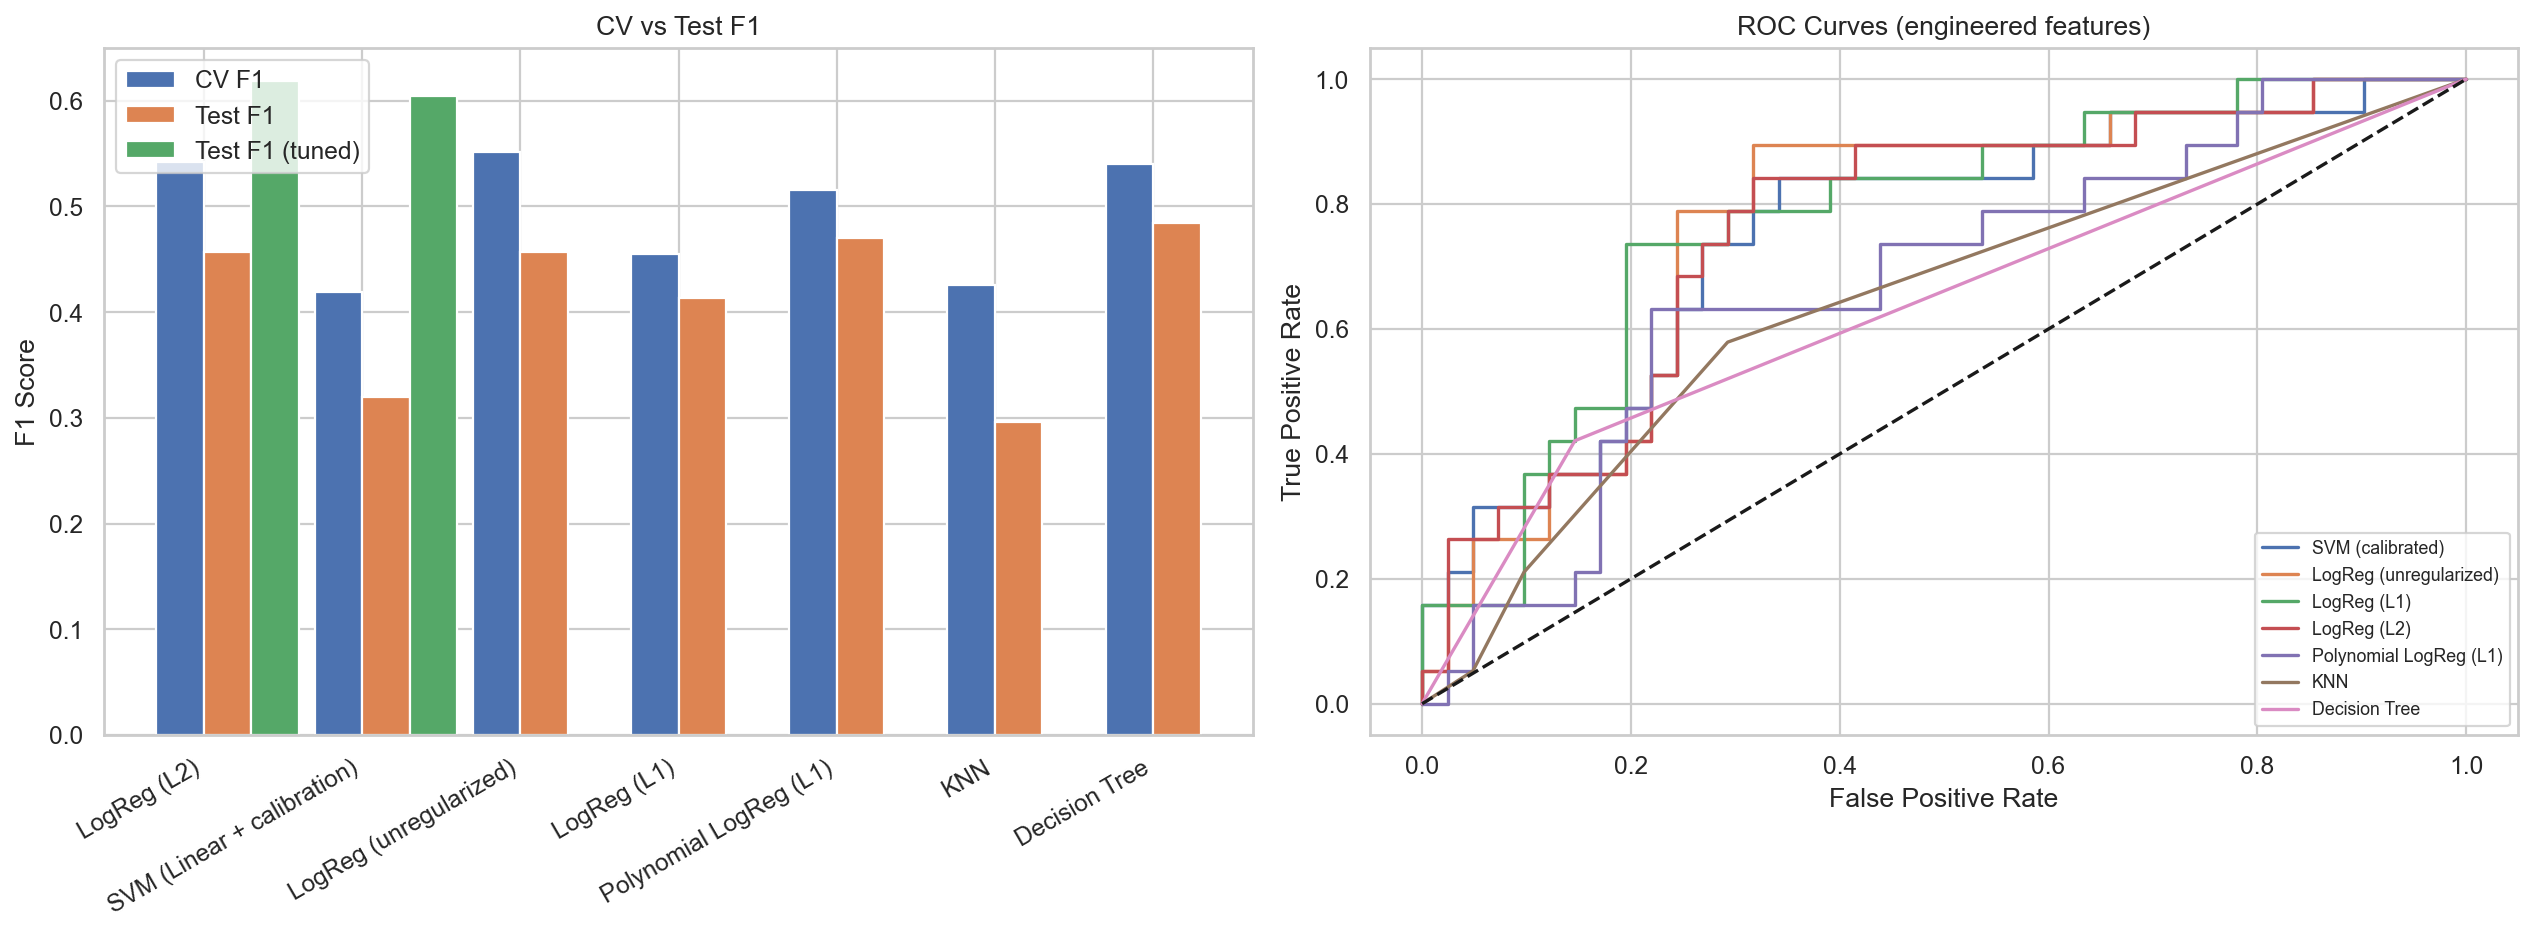

In [50]:
plot_df = final_metrics_df.copy().reset_index().rename(columns={"index": "Model"})
has_tuned = "Test F1 (tuned thr)" in plot_df.columns

models = {
    "SVM (calibrated)": cal_lin,
    "LogReg (unregularized)": pipe,
    "LogReg (L1)": l1pipe_best,
    "LogReg (L2)": l2pipe_best,
    "Polynomial LogReg (L1)": best_polyreg_lr,
    "KNN": best_knn,
    "Decision Tree": dt_pipe,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


ax = axes[0]
x = np.arange(len(plot_df))

ax.bar(x - 0.15, plot_df["CV F1"], width=0.3, label="CV F1")
ax.bar(x + 0.15, plot_df["Test F1"], width=0.3, label="Test F1")

if has_tuned:
    ax.bar(x + 0.45, plot_df["Test F1 (tuned thr)"], width=0.3, label="Test F1 (tuned)")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Model"], rotation=30, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("CV vs Test F1")
ax.legend()

ax = axes[1]

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(Xe_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(Xe_test)
    else:
        continue

    fpr, tpr, _ = roc_curve(ye_test, scores)
    ax.plot(fpr, tpr, label=name)

ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (engineered features)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Model Performance Summary from the Visualizations

From the bar chart, at the default probability threshold of 0.5, the strongest cross validated F1 is from LogReg (unregularized) at about 0.55, followed closely by LogReg (L2) at about 0.54 and Polynomial LogReg (L1) and the Decision Tree at about 0.52. SVM (Linear + calibration) and KNN are lower, with cross validated F1 around 0.42 to 0.43.

On the test set, the best default threshold F1 is from the Decision Tree at about 0.48, with Polynomial LogReg (L1) around 0.47 and both LogReg (unregularized) and LogReg (L2) near 0.46. The SVM and KNN perform less well at this operating point, with test F1 near 0.32 and 0.30. The typical drop of roughly 0.05 to 0.10 from cross validated to test F1 is what we expect from a small imbalanced sample of about 60 test patients rather than a sign of severe overfitting.

The tuned threshold bars show a major improvement for the two linear margin based models. After tuning, LogReg (L2) reaches a test F1 of about 0.62 and the calibrated SVM reaches about 0.60, compared with their default threshold test F1 values of about 0.46 and 0.32. This confirms that these models learn high quality probability rankings but that a fixed 0.5 threshold is not appropriate when only about one third of patients die.

The ROC curves tell a consistent story. Curves for the logistic models and the calibrated SVM lie well above the diagonal reference line, while the curve for KNN is closer to the diagonal. For example, at a false positive rate near 0.2, the better models already achieve true positive rates around 0.6 to 0.7, whereas the weaker ones are closer to 0.5. Overall, the visualizations show that regularized linear models with engineered features provide the best combination of discrimination and stability.


In [51]:
logreg_l2 = l2pipe_best[-1]

if not hasattr(logreg_l2, "coef_"):
    raise TypeError("Final step of l2pipe_best does not expose coef_. Check the pipeline definition.")

coef_l2 = logreg_l2.coef_[0]

log_l2_coef_df = (
    pd.DataFrame({"feature": Xe_train.columns, "coef": coef_l2})
      .assign(abs_coef=lambda df: df["coef"].abs())
      .sort_values("abs_coef", ascending=False)
)

display(log_l2_coef_df[["feature", "coef"]])

,feature,coef
4,ejection_fraction,-1.789189
11,renal_cardio_interaction,0.837491
13,age_ef_interaction,0.752879
2,creatinine_phosphokinase,0.323842
1,anaemia,0.295233
5,high_blood_pressure,0.284774
3,diabetes,0.269595
7,serum_creatinine,0.234938
10,smoking,0.231488
0,age,0.169105


### Clinical Interpretation of Feature Importance

The coefficient table for the LogReg (L2) model on the engineered features makes the decision rule easy to interpret. Because all predictors are standardized, each coefficient represents the change in log odds of death for a one standard deviation increase in that variable, holding everything else fixed.

Ejection_fraction has the strongest coefficient in magnitude at about −1.79, so higher ejection fraction sharply reduces predicted risk. The next largest positive coefficients are renal_cardio_interaction at about 0.84 and age_ef_interaction at about 0.75. These terms indicate that patients who combine impaired renal function and poor ventricular function, or who are older with low ejection fraction, are much more likely to die than would be suggested by any single variable alone.

Several other predictors also have positive coefficients of moderate size. Creatinine_phosphokinase is about 0.32, anaemia about 0.30, high_blood_pressure about 0.28, diabetes about 0.27, serum_creatinine about 0.23 and smoking about 0.23. Age itself still has a positive coefficient around 0.17 even after including the age and ejection fraction interaction, which reflects residual age related risk. On the protective side, sex, serum_sodium and platelets have negative coefficients of about −0.15, −0.11 and −0.10 respectively, which is consistent with hyponatremia and low platelets being markers of severe illness.

The ranking and direction of these coefficients match clinical intuition for heart failure. Preserved ejection fraction, normal sodium and adequate platelet counts are protective, while older age, renal and myocardial stress, anaemia, hypertension, diabetes and smoking increase risk. The fact that this pattern agrees with the coefficient plot for the linear SVM supports the view that our final linear models capture meaningful pathophysiology rather than noise in this small dataset.


## Model Comparison Summary

Bringing the quantitative results and visualizations together, we can summarize the models as follows:

- **Best overall performers (after threshold tuning)**
  L2-regularized logistic regression and the calibrated linear SVM achieve the highest tuned test F1 scores (≈0.62 and 0.60) on the engineered feature space. Both also have strong ROC curves and relatively small gaps between cross-validated and test F1, suggesting good generalization for such a small dataset. The logistic model offers more straightforward coefficient-based interpretation, while the SVM provides a robust margin-based view of the same underlying signal.

- **Strong but slightly less flexible baselines**
  Unregularized and L1-regularized logistic regression obtain similar cross-validated F1 scores in the low-to-mid 0.5s and test F1 scores around 0.41–0.46. They perform well as baselines and confirm that the core linear structure is appropriate, but the L2 variant appears to offer the best compromise between bias (too rigid) and variance (too flexible).

- **Nonlinear models on original vs engineered features**
  Polynomial logistic regression and the depth-limited decision tree also perform competitively, with test F1 around 0.47–0.48 and ROC curves that are clearly above chance. However, they do not substantially outperform the simpler L2 logistic model once the engineered features are available, and they are somewhat more difficult to interpret and tune.

- **k-NN as a weaker benchmark**
  k-NN delivers the lowest test F1 and the weakest ROC curve. This is not surprising: with only ~240 training examples and a modest number of features, distance-based methods are sensitive to noise and class imbalance, and they cannot easily exploit the interaction terms in the same way as the linear models.

From a practical standpoint, these results suggest that **using the engineered feature set together with a regularized linear classifier is sufficient** to capture most of the prognostic structure in this dataset. More complex models do not provide enough additional accuracy to justify their extra tuning burden and opacity, especially in a clinical context where interpretability and robustness are at a premium.


## Conclusions and Future Work

Overall, this analysis shows that mortality risk among patients with heart failure can be modeled reasonably well using a carefully engineered feature set and relatively simple linear classifiers. By constructing clinically motivated interaction terms (cardiorenal interaction, hyponatremia, age × ejection fraction) and standardizing all predictors, we enabled linear models such as L2 logistic regression and linear SVMs to achieve tuned test F1 scores around 0.6 despite the small sample size and class imbalance. The final models highlight intuitive risk factors age, renal function, ejection fraction, sodium levels and behave consistently with established cardiology knowledge.

A key methodological lesson is that **evaluation design matters as much as model choice**. Using a single 0.5 probability threshold in an imbalanced dataset understated performance for several models. Once we used cross-validated decision scores to choose thresholds that maximize F1 for the positive (death) class, both the L2 logistic and calibrated linear SVM models showed substantially better operational performance, without changing the underlying fitted parameters. Similarly, cross-validation and a held-out test set gave us a clear picture of generalization, and regularization plus depth limits prevented the more flexible models from overfitting.

If this work were extended, several avenues could strengthen and validate the findings:

- **Larger and more diverse data**: repeating the analysis on larger cohorts from multiple hospitals, and including additional covariates (e.g., biomarkers, comorbidities, medication history), would improve the stability of estimates and allow richer models without overfitting.
- **Temporal modeling**: our models deliberately excluded follow-up time to avoid leakage. A natural next step would be to move to survival analysis or time-to-event models that explicitly incorporate time and censoring, allowing us to predict not just whether but **when** adverse events are likely.
- **Calibration and decision analysis**: beyond F1 and ROC, formal calibration curves and decision-curve analysis could assess whether the predicted probabilities are well calibrated and whether deploying the model would improve real clinical decision-making at reasonable risk thresholds.

In summary, the combination of engineered clinical features, regularized linear models, and careful evaluation yields an interpretable and reasonably accurate mortality risk model for heart failure patients, while also highlighting clear directions for future improvement in both data collection and modeling methodology.


## Bibliography

1. Huerta-Alardín, A. L., Varon, J., & Marik, P. E. (2005). Bench-to-bedside review:
Rhabdomyolysis an overview for clinicians. *Critical Care*, 9(2), 158–169.

2. Levey, A. S., Bosch, J. P., Lewis, J. B., Greene, T., Rogers, N., & Roth, D. (1999).
A more accurate method to estimate glomerular filtration rate from serum creatinine:
A new prediction equation. *Annals of Internal Medicine*, 130(6), 461–470.

3. NBME. (2025). *Laboratory Reference Values.* National Board of Medical Examiners.

4. Tarpey, M. M., et al. (2006). Evaluation of serum and whole blood sodium critical values.
*Clinical Chemistry*.

5. Yancy, C. W., et al. (2013). 2013 ACCF/AHA guideline for the management of heart failure.
*Journal of the American College of Cardiology*, 62(16), e147–e239.

6. Young, G., & Neunert, C. (2010). Management of immune thrombocytopenic purpura.
*New England Journal of Medicine*.

7. Zhang, X., et al. (2025). Reference intervals for serum creatinine in adults.
*Biomolecules*, 15(1), 41.